In [1]:
from pathlib import Path

project = Path.cwd().parent
raw_data = project / "raw data"

print("Project:", project)
print("Raw data exists:", raw_data.exists())

print("\nFiles in raw data:")
for file in raw_data.iterdir():
    print(file.name)

Project: /Users/dikshadev/    Projects/NYC_HV_FHV_ Analytics_2026
Raw data exists: True

Files in raw data:
fhvhv_tripdata_2026-01.parquet
.DS_Store
fhvhv_tripdata_2026-02.parquet
fhvhv_tripdata_2026-03.parquet


In [2]:
import pandas as pd

feb_file = raw_data / "fhvhv_tripdata_2026-02.parquet"

feb_df = pd.read_parquet(feb_file)

print("Rows:", feb_df.shape[0])
print("Columns:", feb_df.shape[1])

Rows: 19875686
Columns: 25


In [3]:
print("Columns:")
print(feb_df.columns.tolist())

print("\nData types:")
print(feb_df.dtypes)

Columns:
['hvfhs_license_num', 'dispatching_base_num', 'originating_base_num', 'request_datetime', 'on_scene_datetime', 'pickup_datetime', 'dropoff_datetime', 'PULocationID', 'DOLocationID', 'trip_miles', 'trip_time', 'base_passenger_fare', 'tolls', 'bcf', 'sales_tax', 'congestion_surcharge', 'airport_fee', 'tips', 'driver_pay', 'shared_request_flag', 'shared_match_flag', 'access_a_ride_flag', 'wav_request_flag', 'wav_match_flag', 'cbd_congestion_fee']

Data types:
hvfhs_license_num                  str
dispatching_base_num               str
originating_base_num               str
request_datetime        datetime64[us]
on_scene_datetime       datetime64[us]
pickup_datetime         datetime64[us]
dropoff_datetime        datetime64[us]
PULocationID                     int32
DOLocationID                     int32
trip_miles                     float64
trip_time                        int64
base_passenger_fare            float64
tolls                          float64
bcf                    

In [4]:
missing_values = feb_df.isnull().sum()

missing_values[missing_values > 0].sort_values(ascending=False)

originating_base_num    5691209
dtype: int64

In [5]:
feb_originating_missing = (
    feb_df[feb_df["originating_base_num"].isna()]
    .groupby("hvfhs_license_num")
    .size()
    .sort_values(ascending=False)
)

feb_originating_missing

hvfhs_license_num
HV0005    5691209
dtype: int64

In [6]:
feb_df.duplicated().sum()

np.int64(0)

In [7]:
print("Trip miles > 100:", (feb_df["trip_miles"] > 100).sum())
print("Trip time > 4 hours:", (feb_df["trip_time"] > 14400).sum())
print("Zero-mile trips:", (feb_df["trip_miles"] == 0).sum())
print("Zero-time trips:", (feb_df["trip_time"] == 0).sum())
print("Negative passenger fares:", (feb_df["base_passenger_fare"] < 0).sum())
print("Negative driver pay:", (feb_df["driver_pay"] < 0).sum())

Trip miles > 100: 1552
Trip time > 4 hours: 212
Zero-mile trips: 2020
Zero-time trips: 124
Negative passenger fares: 4145
Negative driver pay: 3


In [8]:
feb_df.loc[
    feb_df["base_passenger_fare"] < 0,
    [
        "request_datetime",
        "pickup_datetime",
        "dropoff_datetime",
        "trip_miles",
        "trip_time",
        "base_passenger_fare",
        "tolls",
        "sales_tax",
        "congestion_surcharge",
        "airport_fee",
        "tips",
        "driver_pay"
    ]
].head(20)

,request_datetime,pickup_datetime,dropoff_datetime,trip_miles,trip_time,base_passenger_fare,tolls,sales_tax,congestion_surcharge,airport_fee,tips,driver_pay
42860,2026-02-01 00:25:32,2026-02-01 00:29:00,2026-02-01 00:31:14,0.51,134,-1.01,0.00,0.79,0.00,0.0,0.0,4.50
49790,2026-02-01 01:49:36,2026-02-01 01:54:14,2026-02-01 02:04:05,1.29,590,-2.75,0.00,0.00,2.75,0.0,0.0,19.71
72437,2026-02-01 01:02:04,2026-02-01 01:07:42,2026-02-01 01:26:24,3.10,1122,-1.61,0.00,0.00,2.75,0.0,5.0,24.02
112054,2026-02-01 03:48:42,2026-02-01 03:53:17,2026-02-01 08:12:23,1.81,15546,-30.18,0.00,24.22,2.75,0.0,0.0,57.68
164014,2026-02-01 06:04:49,2026-02-01 06:10:36,2026-02-01 06:29:37,11.08,1141,-2.05,0.00,0.00,0.00,0.0,0.0,31.53
166263,2026-02-01 06:53:56,2026-02-01 06:57:14,2026-02-01 07:05:05,1.32,471,-0.56,0.00,0.00,0.00,0.0,0.0,6.81
168219,2026-02-01 06:42:46,2026-02-01 06:52:56,2026-02-01 07:00:20,1.74,443,-0.82,0.00,0.00,0.00,0.0,0.0,15.06
173362,2026-02-01 06:55:28,2026-02-01 06:59:03,2026-02-01 07:08:46,3.88,583,-2.50,0.00,0.00,0.00,2.5,3.0,11.23
186203,2026-02-01 07:12:48,2026-02-01 07:16:31,2026-02-01 07:52:05,6.85,2134,-1.87,0.00,0.00,0.00,0.0,3.0,31.98
202778,2026-02-01 08:53:16,2026-02-01 08:57:12,2026-02-01 09:19:15,6.43,1323,-2.75,0.00,0.00,2.75,0.0,3.0,22.52


In [9]:
feb_df.loc[
    feb_df["base_passenger_fare"] < 0
].groupby("hvfhs_license_num").size()

hvfhs_license_num
HV0003    4125
HV0005      20
dtype: int64

In [10]:
zero_value_trips = feb_df[
    (feb_df["trip_miles"] == 0) |
    (feb_df["trip_time"] == 0)
]

print("Zero-distance or zero-time trips:", len(zero_value_trips))
print("Zero-distance trips:", (feb_df["trip_miles"] == 0).sum())
print("Zero-time trips:", (feb_df["trip_time"] == 0).sum())

zero_value_trips[
    [
        "pickup_datetime",
        "dropoff_datetime",
        "trip_miles",
        "trip_time",
        "base_passenger_fare",
        "driver_pay",
        "hvfhs_license_num"
    ]
].head(20)

Zero-distance or zero-time trips: 2020
Zero-distance trips: 2020
Zero-time trips: 124


,pickup_datetime,dropoff_datetime,trip_miles,trip_time,base_passenger_fare,driver_pay,hvfhs_license_num
5293,2026-02-01 00:57:40,2026-02-01 01:02:04,0.0,263,6.14,4.89,HV0003
7911,2026-02-01 00:35:43,2026-02-01 00:46:28,0.0,645,35.67,21.03,HV0005
15318,2026-02-01 00:14:38,2026-02-01 00:16:39,0.0,122,26.99,12.88,HV0003
26836,2026-02-01 00:35:35,2026-02-01 00:36:25,0.0,50,10.71,7.00,HV0003
31463,2026-02-01 00:46:52,2026-02-01 00:54:39,0.0,467,18.17,15.18,HV0003
45277,2026-02-01 01:27:59,2026-02-01 01:37:09,0.0,550,7.36,6.06,HV0003
57576,2026-02-01 01:33:19,2026-02-01 01:38:44,0.0,326,42.01,21.63,HV0003
59900,2026-02-01 01:23:55,2026-02-01 01:26:17,0.0,142,21.88,15.61,HV0003
60377,2026-02-01 01:45:41,2026-02-01 01:45:55,0.0,14,10.85,14.90,HV0005
61864,2026-02-01 01:51:36,2026-02-01 01:53:58,0.0,141,26.99,12.91,HV0003


In [11]:
feb_zero_time = feb_df[feb_df["trip_time"] == 0]

print("Zero-time trips:", len(feb_zero_time))

feb_zero_time[
    [
        "request_datetime",
        "pickup_datetime",
        "dropoff_datetime",
        "trip_miles",
        "trip_time",
        "base_passenger_fare",
        "driver_pay",
        "hvfhs_license_num"
    ]
].head(20)

Zero-time trips: 124


,request_datetime,pickup_datetime,dropoff_datetime,trip_miles,trip_time,base_passenger_fare,driver_pay,hvfhs_license_num
798309,2026-02-02 03:46:50,2026-02-02 03:54:24,2026-02-02 04:00:20.433,0.0,0,0.00,0.08,HV0003
854554,2026-02-02 07:47:39,2026-02-02 07:52:27,2026-02-02 08:13:10.000,0.0,0,41.29,21.03,HV0003
871718,2026-02-02 07:16:40,2026-02-02 07:20:35,2026-02-02 08:11:04.000,0.0,0,69.42,54.44,HV0003
876358,2026-02-02 07:39:23,2026-02-02 07:51:48,2026-02-02 08:16:55.393,0.0,0,0.00,0.75,HV0003
885463,2026-02-02 08:16:58,2026-02-02 08:30:31,2026-02-02 09:20:03.000,0.0,0,29.08,43.12,HV0003
896557,2026-02-02 07:34:45,2026-02-02 08:00:26,2026-02-02 08:14:59.000,0.0,0,13.72,13.85,HV0003
902610,2026-02-02 08:38:50,2026-02-02 08:44:56,2026-02-02 08:56:56.000,0.0,0,26.25,15.78,HV0003
909614,2026-02-02 08:22:29,2026-02-02 08:31:54,2026-02-02 09:03:45.000,0.0,0,20.48,28.53,HV0003
912951,2026-02-02 08:33:00,2026-02-02 08:39:28,2026-02-02 09:02:19.000,0.0,0,42.42,28.51,HV0003
914398,2026-02-02 08:17:31,2026-02-02 08:19:04,2026-02-02 08:41:49.000,0.0,0,20.24,18.50,HV0003


In [12]:
feb_df["calculated_trip_time"] = (
    feb_df["dropoff_datetime"] - feb_df["pickup_datetime"]
).dt.total_seconds()

print("Rows where recorded trip_time = 0 but calculated duration > 0:",
      (
          (feb_df["trip_time"] == 0) &
          (feb_df["calculated_trip_time"] > 0)
      ).sum())

print("\nSample:")
feb_df.loc[
    (feb_df["trip_time"] == 0) &
    (feb_df["calculated_trip_time"] > 0),
    [
        "pickup_datetime",
        "dropoff_datetime",
        "trip_time",
        "calculated_trip_time",
        "trip_miles",
        "base_passenger_fare",
        "driver_pay"
    ]
].head(10)

Rows where recorded trip_time = 0 but calculated duration > 0: 124

Sample:


,pickup_datetime,dropoff_datetime,trip_time,calculated_trip_time,trip_miles,base_passenger_fare,driver_pay
798309,2026-02-02 03:54:24,2026-02-02 04:00:20.433,0,356.433,0.0,0.00,0.08
854554,2026-02-02 07:52:27,2026-02-02 08:13:10.000,0,1243.000,0.0,41.29,21.03
871718,2026-02-02 07:20:35,2026-02-02 08:11:04.000,0,3029.000,0.0,69.42,54.44
876358,2026-02-02 07:51:48,2026-02-02 08:16:55.393,0,1507.393,0.0,0.00,0.75
885463,2026-02-02 08:30:31,2026-02-02 09:20:03.000,0,2972.000,0.0,29.08,43.12
896557,2026-02-02 08:00:26,2026-02-02 08:14:59.000,0,873.000,0.0,13.72,13.85
902610,2026-02-02 08:44:56,2026-02-02 08:56:56.000,0,720.000,0.0,26.25,15.78
909614,2026-02-02 08:31:54,2026-02-02 09:03:45.000,0,1911.000,0.0,20.48,28.53
912951,2026-02-02 08:39:28,2026-02-02 09:02:19.000,0,1371.000,0.0,42.42,28.51
914398,2026-02-02 08:19:04,2026-02-02 08:41:49.000,0,1365.000,0.0,20.24,18.50


In [13]:
duration_diff = (
    feb_df["trip_time"] - feb_df["calculated_trip_time"]
).abs()

print("Exact duration matches:",
      (duration_diff < 1).sum())

print("Duration mismatches:",
      (duration_diff >= 1).sum())

print("Mismatch percentage:",
      round((duration_diff >= 1).mean() * 100, 2), "%")

Exact duration matches: 16303580
Duration mismatches: 3572106
Mismatch percentage: 17.97 %


In [14]:
duration_diff.describe(percentiles=[0.50, 0.75, 0.90, 0.95, 0.99])

count    1.987569e+07
mean     2.124284e-01
std      7.519734e+00
min      0.000000e+00
50%      0.000000e+00
75%      0.000000e+00
90%      1.000000e+00
95%      1.000000e+00
99%      1.000000e+00
max      1.411300e+04
dtype: float64

In [15]:
print("Difference >= 5 min:", (duration_diff >= 300).sum())
print("Difference >= 15 min:", (duration_diff >= 900).sum())
print("Difference >= 30 min:", (duration_diff >= 1800).sum())
print("Difference >= 1 hour:", (duration_diff >= 3600).sum())

Difference >= 5 min: 594
Difference >= 15 min: 295
Difference >= 30 min: 61
Difference >= 1 hour: 6


In [16]:
feb_duration_outliers = feb_df.loc[
    duration_diff >= 1800,
    [
        "request_datetime",
        "pickup_datetime",
        "dropoff_datetime",
        "trip_time",
        "calculated_trip_time",
        "trip_miles",
        "base_passenger_fare",
        "driver_pay",
        "hvfhs_license_num"
    ]
].copy()

feb_duration_outliers["duration_diff"] = duration_diff[duration_diff >= 1800]

feb_duration_outliers.sort_values(
    "duration_diff",
    ascending=False
).head(20)

,request_datetime,pickup_datetime,dropoff_datetime,trip_time,calculated_trip_time,trip_miles,base_passenger_fare,driver_pay,hvfhs_license_num,duration_diff
11541124,2026-02-16 16:58:34,2026-02-16 13:08:19.000,2026-02-16 20:58:47.000,14115,28228.000,0.75,-24.21,15.49,HV0003,14113.000
6900882,2026-02-10 09:43:49,2026-02-10 08:12:34.000,2026-02-10 11:34:48.000,6192,12134.000,8.15,101.95,78.12,HV0003,5942.000
7663163,2026-02-11 09:52:00,2026-02-11 10:25:26.000,2026-02-11 12:02:02.596,0,5796.596,0.00,0.00,0.00,HV0003,5796.596
14699096,2026-02-21 03:51:28,2026-02-21 04:16:05.000,2026-02-21 05:32:24.256,0,4579.256,0.00,0.00,0.00,HV0003,4579.256
14218274,2026-02-20 16:32:31,2026-02-20 15:32:04.000,2026-02-20 17:44:18.000,4110,7934.000,13.35,158.06,93.13,HV0003,3824.000
10330933,2026-02-14 20:21:50,2026-02-14 19:32:43.000,2026-02-14 21:34:20.000,3687,7297.000,15.54,57.84,70.85,HV0003,3610.000
1163886,2026-02-02 16:52:57,2026-02-02 16:55:26.000,2026-02-02 17:55:12.000,0,3586.000,0.00,43.72,53.07,HV0003,3586.000
838536,2026-02-02 06:52:33,2026-02-02 06:00:33.000,2026-02-02 07:54:33.000,3586,6840.000,0.90,2.23,41.97,HV0003,3254.000
6870522,2026-02-10 06:39:00,2026-02-10 07:01:07.000,2026-02-10 09:00:42.000,4090,7175.000,20.18,108.00,95.00,HV0003,3085.000
3101167,2026-02-05 13:47:04,2026-02-05 13:52:34.000,2026-02-05 14:43:03.776,0,3029.776,0.00,0.00,0.00,HV0003,3029.776


In [17]:
feb_duration_outliers.groupby(
    "hvfhs_license_num"
).size().sort_values(ascending=False)

hvfhs_license_num
HV0003    61
dtype: int64

In [18]:
invalid_time_order = (
    feb_df["dropoff_datetime"] < feb_df["pickup_datetime"]
).sum()

print("Dropoff before pickup:", invalid_time_order)

Dropoff before pickup: 0


In [19]:
print("Invalid pickup Location IDs:",
      ((feb_df["PULocationID"] < 1) | (feb_df["PULocationID"] > 265)).sum())

print("Invalid dropoff Location IDs:",
      ((feb_df["DOLocationID"] < 1) | (feb_df["DOLocationID"] > 265)).sum())

Invalid pickup Location IDs: 0
Invalid dropoff Location IDs: 0


In [20]:
flag_columns = [
    "shared_request_flag",
    "shared_match_flag",
    "access_a_ride_flag",
    "wav_request_flag",
    "wav_match_flag"
]

for col in flag_columns:
    print(f"\n{col}:")
    print(feb_df[col].value_counts(dropna=False))


shared_request_flag:
shared_request_flag
N    19489921
Y      385765
Name: count, dtype: int64

shared_match_flag:
shared_match_flag
N    19656388
Y      219298
Name: count, dtype: int64

access_a_ride_flag:
access_a_ride_flag
N    19857217
Y       18469
Name: count, dtype: int64

wav_request_flag:
wav_request_flag
N    19828171
Y       47515
Name: count, dtype: int64

wav_match_flag:
wav_match_flag
N    18030622
Y     1845064
Name: count, dtype: int64


In [21]:
print(
    "On-scene before request:",
    (feb_df["on_scene_datetime"] < feb_df["request_datetime"]).sum()
)

print(
    "Pickup before request:",
    (feb_df["pickup_datetime"] < feb_df["request_datetime"]).sum()
)

print(
    "Pickup before on-scene:",
    (feb_df["pickup_datetime"] < feb_df["on_scene_datetime"]).sum()
)

print(
    "Dropoff before on-scene:",
    (feb_df["dropoff_datetime"] < feb_df["on_scene_datetime"]).sum()
)

On-scene before request: 384263
Pickup before request: 280622
Pickup before on-scene: 660
Dropoff before on-scene: 0


In [22]:
timestamp_issues = feb_df[
    (feb_df["on_scene_datetime"] < feb_df["request_datetime"]) |
    (feb_df["pickup_datetime"] < feb_df["request_datetime"])
][[
    "hvfhs_license_num",
    "request_datetime",
    "on_scene_datetime",
    "pickup_datetime",
    "dropoff_datetime",
    "trip_time",
    "trip_miles",
    "base_passenger_fare",
    "driver_pay"
]]

timestamp_issues.head(20)

,hvfhs_license_num,request_datetime,on_scene_datetime,pickup_datetime,dropoff_datetime,trip_time,trip_miles,base_passenger_fare,driver_pay
43,HV0003,2026-02-01 00:00:00,2026-01-31 23:51:15,2026-02-01 00:00:43,2026-02-01 00:21:28,1245,11.260,34.65,32.91
997,HV0005,2026-02-01 00:35:01,2026-02-01 00:31:38,2026-02-01 00:32:16,2026-02-01 01:05:50,2014,8.219,57.06,37.32
1889,HV0003,2026-02-01 00:50:00,2026-02-01 00:44:18,2026-02-01 00:45:08,2026-02-01 01:17:19,1931,19.430,109.45,65.30
2415,HV0005,2026-02-01 00:05:01,2026-01-31 23:57:47,2026-02-01 00:01:30,2026-02-01 00:17:23,953,1.095,15.43,25.83
2851,HV0003,2026-02-01 00:15:00,2026-02-01 00:06:51,2026-02-01 00:07:07,2026-02-01 00:15:24,498,2.550,9.23,8.61
3614,HV0003,2026-02-01 00:25:00,2026-02-01 00:16:55,2026-02-01 00:20:15,2026-02-01 00:42:35,1340,10.730,63.68,38.75
3981,HV0003,2026-02-01 00:30:00,2026-02-01 00:15:35,2026-02-01 00:25:29,2026-02-01 00:56:39,1869,6.810,41.45,38.63
4630,HV0003,2026-02-01 00:25:00,2026-02-01 00:15:21,2026-02-01 00:16:35,2026-02-01 00:58:42,2527,11.080,25.98,42.21
4939,HV0003,2026-02-01 00:25:00,2026-02-01 00:16:32,2026-02-01 00:19:09,2026-02-01 00:36:59,1069,3.760,56.96,31.86
5303,HV0003,2026-02-01 01:00:00,2026-02-01 00:52:07,2026-02-01 00:53:52,2026-02-01 02:19:49,5157,74.520,187.54,172.41


In [23]:
request_on_scene_diff = (
    feb_df["on_scene_datetime"] - feb_df["request_datetime"]
).dt.total_seconds()

request_pickup_diff = (
    feb_df["pickup_datetime"] - feb_df["request_datetime"]
).dt.total_seconds()

print("On-scene vs request:")
print(request_on_scene_diff.describe(percentiles=[0.01, 0.05, 0.25, 0.50, 0.75, 0.95, 0.99]))

print("\nPickup vs request:")
print(request_pickup_diff.describe(percentiles=[0.01, 0.05, 0.25, 0.50, 0.75, 0.95, 0.99]))

On-scene vs request:
count    1.987569e+07
mean     2.664195e+02
std      2.621530e+02
min     -8.738900e+04
1%      -4.950000e+02
5%       3.800000e+01
25%      1.280000e+02
50%      2.190000e+02
75%      3.570000e+02
95%      7.290000e+02
99%      1.080000e+03
max      2.322300e+04
dtype: float64

Pickup vs request:
count    1.987569e+07
mean     3.249534e+02
std      2.507446e+02
min     -8.609100e+04
1%      -1.570000e+02
5%       9.200000e+01
25%      1.840000e+02
50%      2.720000e+02
75%      4.090000e+02
95%      7.820000e+02
99%      1.139000e+03
max      2.472600e+04
dtype: float64


In [24]:
print("On-scene before request:")
print((request_on_scene_diff < 0).sum())

print("\nPickup before request:")
print((request_pickup_diff < 0).sum())

print("\nOn-scene > 1 hour before request:")
print((request_on_scene_diff < -3600).sum())

print("\nPickup > 1 hour before request:")
print((request_pickup_diff < -3600).sum())

On-scene before request:
384263

Pickup before request:
280622

On-scene > 1 hour before request:
49

Pickup > 1 hour before request:
19


In [25]:
extreme_timestamp_issues = feb_df[
    (request_on_scene_diff < -3600) |
    (request_pickup_diff < -3600)
][[
    "hvfhs_license_num",
    "request_datetime",
    "on_scene_datetime",
    "pickup_datetime",
    "dropoff_datetime",
    "trip_time",
    "trip_miles",
    "base_passenger_fare",
    "driver_pay"
]]

extreme_timestamp_issues

,hvfhs_license_num,request_datetime,on_scene_datetime,pickup_datetime,dropoff_datetime,trip_time,trip_miles,base_passenger_fare,driver_pay
457261,HV0005,2026-02-01 16:50:00,2026-02-01 15:39:07,2026-02-01 15:40:07,2026-02-01 16:44:46,3879,40.921,147.80,99.69
617451,HV0003,2026-02-01 19:41:00,2026-02-01 18:35:21,2026-02-01 19:12:16,2026-02-01 19:39:27,1631,15.750,91.82,79.47
1275923,HV0003,2026-02-02 19:45:00,2026-02-02 18:35:58,2026-02-02 19:41:22,2026-02-02 20:25:59,2677,27.550,95.57,96.68
1296389,HV0003,2026-02-02 19:15:00,2026-02-02 18:09:43,2026-02-02 19:17:44,2026-02-02 20:50:06,5542,63.340,234.47,219.42
1834337,HV0003,2026-02-03 18:05:00,2026-02-03 16:00:47,2026-02-03 16:40:47,2026-02-03 18:20:52,6005,60.790,253.65,166.58
2766442,HV0003,2026-02-05 23:00:00,2026-02-04 22:43:31,2026-02-04 23:05:09,2026-02-04 23:25:52,1243,13.510,108.39,58.50
2924272,HV0003,2026-02-05 09:10:00,2026-02-05 07:50:51,2026-02-05 08:37:23,2026-02-05 10:07:07,5384,56.960,235.92,267.53
3084854,HV0005,2026-02-05 14:15:00,2026-02-05 13:10:41,2026-02-05 13:10:41,2026-02-05 14:13:45,3784,24.912,111.08,74.25
3567522,HV0005,2026-02-06 06:15:00,2026-02-06 05:07:22,2026-02-06 05:07:22,2026-02-06 05:43:40,2178,15.698,49.56,50.70
3964729,HV0005,2026-02-06 18:35:00,2026-02-06 17:24:27,2026-02-06 17:24:27,2026-02-06 18:22:49,3502,17.803,89.15,60.56


In [26]:
extreme_timestamp_issues.groupby(
    "hvfhs_license_num"
).size().sort_values(ascending=False)

hvfhs_license_num
HV0003    39
HV0005    13
dtype: int64

In [27]:
feb_df.loc[
    feb_df["originating_base_num"].isna()
].groupby(
    "hvfhs_license_num"
).size().sort_values(ascending=False)

hvfhs_license_num
HV0005    5691209
dtype: int64

In [28]:
provider_missing_summary = (
    feb_df.groupby("hvfhs_license_num")
    .agg(
        total_records=("hvfhs_license_num", "size"),
        missing_originating_base=("originating_base_num", lambda x: x.isna().sum())
    )
)

provider_missing_summary["missing_pct"] = (
    provider_missing_summary["missing_originating_base"]
    / provider_missing_summary["total_records"]
    * 100
).round(2)

provider_missing_summary

,total_records,missing_originating_base,missing_pct
hvfhs_license_num,,,
HV0003,14166961,0,0.00
HV0005,5708725,5691209,99.69


In [29]:
feb_df.isna().sum().sort_values(ascending=False)

originating_base_num    5691209
hvfhs_license_num             0
sales_tax                     0
cbd_congestion_fee            0
wav_match_flag                0
wav_request_flag              0
access_a_ride_flag            0
shared_match_flag             0
shared_request_flag           0
driver_pay                    0
tips                          0
airport_fee                   0
congestion_surcharge          0
bcf                           0
dispatching_base_num          0
tolls                         0
base_passenger_fare           0
trip_time                     0
trip_miles                    0
DOLocationID                  0
PULocationID                  0
dropoff_datetime              0
pickup_datetime               0
on_scene_datetime             0
request_datetime              0
calculated_trip_time          0
dtype: int64

In [30]:
feb_long_distance = feb_df.loc[
    feb_df["trip_miles"] > 100,
    [
        "hvfhs_license_num",
        "request_datetime",
        "pickup_datetime",
        "dropoff_datetime",
        "trip_miles",
        "trip_time",
        "base_passenger_fare",
        "driver_pay"
    ]
]

feb_long_distance.sort_values(
    "trip_miles",
    ascending=False
).head(20)

,hvfhs_license_num,request_datetime,pickup_datetime,dropoff_datetime,trip_miles,trip_time,base_passenger_fare,driver_pay
8900562,HV0003,2026-02-12 23:29:00,2026-02-13 00:17:48,2026-02-13 00:39:52,1625.940,1325,88.04,51.51
2545290,HV0003,2026-02-04 16:21:00,2026-02-04 17:17:08,2026-02-04 18:05:20,1439.110,2892,78.79,51.50
2524599,HV0003,2026-02-04 16:45:00,2026-02-04 17:22:26,2026-02-04 18:00:31,1434.320,2285,79.18,51.54
1900574,HV0003,2026-02-03 18:11:43,2026-02-03 18:15:39,2026-02-04 03:32:24,547.340,33405,1023.53,1215.01
9573657,HV0003,2026-02-13 21:14:23,2026-02-13 21:23:25,2026-02-14 06:15:12,508.580,31907,1279.03,981.86
16010288,HV0005,2026-02-23 11:29:07,2026-02-23 11:33:53,2026-02-23 17:35:35,356.079,21702,954.38,864.90
15613626,HV0005,2026-02-22 07:46:19,2026-02-22 08:03:46,2026-02-22 13:37:08,347.596,20002,1269.76,939.22
11965836,HV0005,2026-02-17 07:01:49,2026-02-17 07:04:57,2026-02-17 15:01:29,323.162,28592,955.79,883.35
6748101,HV0005,2026-02-09 23:05:30,2026-02-09 23:08:41,2026-02-10 04:15:48,296.853,18427,1136.99,818.95
7351008,HV0005,2026-02-10 21:00:44,2026-02-10 21:08:19,2026-02-11 01:38:29,293.553,16210,817.61,688.43


In [31]:
feb_long_distance = feb_long_distance.copy()

feb_long_distance["speed_mph"] = (
    feb_long_distance["trip_miles"]
    / (feb_long_distance["trip_time"] / 3600)
)

feb_long_distance.sort_values(
    "speed_mph",
    ascending=False
).head(20)

,hvfhs_license_num,request_datetime,pickup_datetime,dropoff_datetime,trip_miles,trip_time,base_passenger_fare,driver_pay,speed_mph
8900562,HV0003,2026-02-12 23:29:00,2026-02-13 00:17:48,2026-02-13 00:39:52,1625.940,1325,88.04,51.51,4417.648302
2524599,HV0003,2026-02-04 16:45:00,2026-02-04 17:22:26,2026-02-04 18:00:31,1434.320,2285,79.18,51.54,2259.760175
2545290,HV0003,2026-02-04 16:21:00,2026-02-04 17:17:08,2026-02-04 18:05:20,1439.110,2892,78.79,51.50,1791.423237
3772309,HV0003,2026-02-06 09:42:00,2026-02-06 11:43:46,2026-02-06 12:21:16,234.600,2250,87.49,54.99,375.360000
17129967,HV0003,2026-02-25 10:43:00,2026-02-25 13:42:52,2026-02-25 14:39:47,236.560,3415,125.72,71.70,249.375110
9812320,HV0005,2026-02-14 03:07:17,2026-02-14 03:19:38,2026-02-14 05:30:06,185.410,7828,552.89,401.99,85.267757
16050437,HV0005,2026-02-23 16:41:14,2026-02-23 16:43:12,2026-02-23 20:28:11,269.873,13499,792.86,616.51,71.971465
16036667,HV0003,2026-02-23 15:30:00,2026-02-23 15:28:32,2026-02-23 18:59:20,252.110,12648,1069.67,600.18,71.758065
16085197,HV0003,2026-02-23 19:04:14,2026-02-23 19:14:59,2026-02-23 22:50:40,256.470,12941,889.92,535.60,71.346264
7355239,HV0005,2026-02-10 22:01:00,2026-02-10 21:24:21,2026-02-10 23:43:01,154.642,8320,488.59,414.39,66.912404


In [32]:
print("Speed > 100 mph:", (feb_long_distance["speed_mph"] > 100).sum())
print("Speed > 150 mph:", (feb_long_distance["speed_mph"] > 150).sum())
print("Speed > 200 mph:", (feb_long_distance["speed_mph"] > 200).sum())
print("Speed > 300 mph:", (feb_long_distance["speed_mph"] > 300).sum())

Speed > 100 mph: 5
Speed > 150 mph: 5
Speed > 200 mph: 5
Speed > 300 mph: 4


In [34]:
feb_extreme_speed = feb_long_distance.loc[
    feb_long_distance["speed_mph"] > 100,
    [
        "hvfhs_license_num",
        "request_datetime",
        "pickup_datetime",
        "dropoff_datetime",
        "trip_miles",
        "trip_time",
        "base_passenger_fare",
        "driver_pay",
        "speed_mph"
    ]
].sort_values("speed_mph", ascending=False)

feb_extreme_speed

,hvfhs_license_num,request_datetime,pickup_datetime,dropoff_datetime,trip_miles,trip_time,base_passenger_fare,driver_pay,speed_mph
8900562,HV0003,2026-02-12 23:29:00,2026-02-13 00:17:48,2026-02-13 00:39:52,1625.94,1325,88.04,51.51,4417.648302
2524599,HV0003,2026-02-04 16:45:00,2026-02-04 17:22:26,2026-02-04 18:00:31,1434.32,2285,79.18,51.54,2259.760175
2545290,HV0003,2026-02-04 16:21:00,2026-02-04 17:17:08,2026-02-04 18:05:20,1439.11,2892,78.79,51.50,1791.423237
3772309,HV0003,2026-02-06 09:42:00,2026-02-06 11:43:46,2026-02-06 12:21:16,234.60,2250,87.49,54.99,375.360000
17129967,HV0003,2026-02-25 10:43:00,2026-02-25 13:42:52,2026-02-25 14:39:47,236.56,3415,125.72,71.70,249.375110


In [36]:
feb_df["extreme_speed_flag"] = (
    (feb_df["trip_time"] > 0) &
    (
        feb_df["trip_miles"] /
        (feb_df["trip_time"] / 3600)
        > 100
    )
)

print("Extreme-speed records:", feb_df["extreme_speed_flag"].sum())

Extreme-speed records: 7


In [37]:
feb_extreme_speed = feb_df.loc[
    feb_df["extreme_speed_flag"],
    [
        "hvfhs_license_num",
        "request_datetime",
        "pickup_datetime",
        "dropoff_datetime",
        "trip_miles",
        "trip_time",
        "base_passenger_fare",
        "driver_pay"
    ]
].copy()

feb_extreme_speed["speed_mph"] = (
    feb_extreme_speed["trip_miles"] /
    (feb_extreme_speed["trip_time"] / 3600)
)

feb_extreme_speed.sort_values(
    "speed_mph",
    ascending=False
)

,hvfhs_license_num,request_datetime,pickup_datetime,dropoff_datetime,trip_miles,trip_time,base_passenger_fare,driver_pay,speed_mph
8900562,HV0003,2026-02-12 23:29:00,2026-02-13 00:17:48,2026-02-13 00:39:52,1625.940,1325,88.04,51.51,4417.648302
2524599,HV0003,2026-02-04 16:45:00,2026-02-04 17:22:26,2026-02-04 18:00:31,1434.320,2285,79.18,51.54,2259.760175
2545290,HV0003,2026-02-04 16:21:00,2026-02-04 17:17:08,2026-02-04 18:05:20,1439.110,2892,78.79,51.50,1791.423237
3772309,HV0003,2026-02-06 09:42:00,2026-02-06 11:43:46,2026-02-06 12:21:16,234.600,2250,87.49,54.99,375.360000
17129967,HV0003,2026-02-25 10:43:00,2026-02-25 13:42:52,2026-02-25 14:39:47,236.560,3415,125.72,71.70,249.375110
15544059,HV0003,2026-02-22 05:30:00,2026-02-22 05:23:56,2026-02-22 05:53:25,8.960,296,44.20,22.02,108.972973
13733365,HV0005,2026-02-19 22:40:20,2026-02-19 22:46:21,2026-02-19 22:46:22,0.029,1,9.64,4.00,104.400000


In [38]:
feb_df.loc[
    feb_df["trip_time"] <= 5,
    [
        "hvfhs_license_num",
        "request_datetime",
        "pickup_datetime",
        "dropoff_datetime",
        "trip_time",
        "trip_miles",
        "base_passenger_fare",
        "driver_pay"
    ]
].sort_values("trip_time").head(20)

,hvfhs_license_num,request_datetime,pickup_datetime,dropoff_datetime,trip_time,trip_miles,base_passenger_fare,driver_pay
7541313,HV0003,2026-02-11 07:24:33,2026-02-11 07:30:06.000,2026-02-11 07:34:01.000,0,0.0,8.41,4.32
4425957,HV0003,2026-02-07 06:12:23,2026-02-07 06:20:25.000,2026-02-07 06:28:00.000,0,0.0,11.90,8.63
17096203,HV0003,2026-02-25 12:20:00,2026-02-25 12:18:01.000,2026-02-25 12:47:58.740,0,0.0,0.00,0.00
10741129,HV0003,2026-02-15 07:31:29,2026-02-15 07:33:56.000,2026-02-15 07:50:23.330,0,0.0,0.00,0.00
17471035,HV0003,2026-02-25 22:44:10,2026-02-25 22:50:37.000,2026-02-25 23:05:00.000,0,0.0,33.16,17.79
17705277,HV0003,2026-02-26 09:01:43,2026-02-26 09:09:25.156,2026-02-26 09:53:19.760,0,0.0,0.00,0.00
12553904,HV0003,2026-02-18 07:30:58,2026-02-18 07:33:52.000,2026-02-18 07:55:19.586,0,0.0,0.00,0.00
3631275,HV0003,2026-02-06 07:26:02,2026-02-06 07:32:40.000,2026-02-06 07:53:21.586,0,0.0,0.00,0.00
11792630,HV0003,2026-02-16 21:25:09,2026-02-16 21:27:47.000,2026-02-16 21:49:55.000,0,0.0,32.76,25.05
3186068,HV0003,2026-02-05 16:51:17,2026-02-05 16:55:41.000,2026-02-05 17:08:51.943,0,0.0,0.00,0.00


In [39]:
feb_df["actual_trip_time"] = (
    feb_df["dropoff_datetime"] - feb_df["pickup_datetime"]
).dt.total_seconds()

print("Records where recorded trip_time = 0:",
      (feb_df["trip_time"] == 0).sum())

print("Of these, actual duration > 0:",
      ((feb_df["trip_time"] == 0) & (feb_df["actual_trip_time"] > 0)).sum())

print("Of these, actual duration = 0:",
      ((feb_df["trip_time"] == 0) & (feb_df["actual_trip_time"] == 0)).sum())

print("\nActual duration for trip_time = 0:")
print(
    feb_df.loc[
        feb_df["trip_time"] == 0,
        "actual_trip_time"
    ].describe()
)

Records where recorded trip_time = 0: 124
Of these, actual duration > 0: 124
Of these, actual duration = 0: 0

Actual duration for trip_time = 0:
count     124.000000
mean     1309.507137
std       891.995976
min       180.000000
25%       706.354000
50%      1109.500000
75%      1725.250000
max      5796.596000
Name: actual_trip_time, dtype: float64


In [40]:
zero_time_check = feb_df.loc[
    feb_df["trip_time"] == 0,
    [
        "trip_miles",
        "base_passenger_fare",
        "driver_pay",
        "actual_trip_time"
    ]
]

print("trip_time = 0 records:", len(zero_time_check))
print("trip_miles = 0:", (zero_time_check["trip_miles"] == 0).sum())
print("trip_miles > 0:", (zero_time_check["trip_miles"] > 0).sum())

print("\nSummary:")
print(zero_time_check.describe())

trip_time = 0 records: 124
trip_miles = 0: 124
trip_miles > 0: 0

Summary:
       trip_miles  base_passenger_fare  driver_pay  actual_trip_time
count       124.0           124.000000  124.000000        124.000000
mean          0.0            19.473952   14.722097       1309.507137
std           0.0            20.061622   14.040856        891.995976
min           0.0             0.000000    0.000000        180.000000
25%           0.0             5.055000    3.307500        706.354000
50%           0.0            15.160000   11.910000       1109.500000
75%           0.0            26.405000   20.850000       1725.250000
max           0.0           104.090000   58.070000       5796.596000


In [41]:
zero_time_location_check = feb_df.loc[
    feb_df["trip_time"] == 0,
    [
        "PULocationID",
        "DOLocationID",
        "base_passenger_fare",
        "driver_pay"
    ]
]

print("Records with missing pickup location:",
      zero_time_location_check["PULocationID"].isna().sum())

print("Records with missing dropoff location:",
      zero_time_location_check["DOLocationID"].isna().sum())

print("\nUnique pickup locations:",
      zero_time_location_check["PULocationID"].nunique())

print("Unique dropoff locations:",
      zero_time_location_check["DOLocationID"].nunique())

Records with missing pickup location: 0
Records with missing dropoff location: 0

Unique pickup locations: 82
Unique dropoff locations: 73


In [42]:
negative_fare_summary = feb_df.loc[
    feb_df["base_passenger_fare"] < 0
].groupby("hvfhs_license_num").agg(
    negative_fare_records=("base_passenger_fare", "size"),
    avg_negative_fare=("base_passenger_fare", "mean"),
    min_negative_fare=("base_passenger_fare", "min")
).sort_values("negative_fare_records", ascending=False)

negative_fare_summary

,negative_fare_records,avg_negative_fare,min_negative_fare
hvfhs_license_num,,,
HV0003,4125,-3.583377,-60.36
HV0005,20,-8.570000,-27.35


In [43]:
negative_fare_check = feb_df.loc[
    feb_df["base_passenger_fare"] < 0,
    [
        "hvfhs_license_num",
        "trip_miles",
        "trip_time",
        "base_passenger_fare",
        "tolls",
        "sales_tax",
        "congestion_surcharge",
        "airport_fee",
        "tips",
        "driver_pay"
    ]
]

print("Negative-fare records:", len(negative_fare_check))

print("\nTrip miles:")
print((negative_fare_check["trip_miles"] > 0).sum())

print("\nTrip time:")
print((negative_fare_check["trip_time"] > 0).sum())

print("\nDriver pay > 0:")
print((negative_fare_check["driver_pay"] > 0).sum())

print("\nSample:")
negative_fare_check.head(10)

Negative-fare records: 4145

Trip miles:
4033

Trip time:
4145

Driver pay > 0:
4139

Sample:


,hvfhs_license_num,trip_miles,trip_time,base_passenger_fare,tolls,sales_tax,congestion_surcharge,airport_fee,tips,driver_pay
42860,HV0003,0.51,134,-1.01,0.0,0.79,0.00,0.0,0.0,4.50
49790,HV0003,1.29,590,-2.75,0.0,0.00,2.75,0.0,0.0,19.71
72437,HV0003,3.10,1122,-1.61,0.0,0.00,2.75,0.0,5.0,24.02
112054,HV0003,1.81,15546,-30.18,0.0,24.22,2.75,0.0,0.0,57.68
164014,HV0003,11.08,1141,-2.05,0.0,0.00,0.00,0.0,0.0,31.53
166263,HV0003,1.32,471,-0.56,0.0,0.00,0.00,0.0,0.0,6.81
168219,HV0003,1.74,443,-0.82,0.0,0.00,0.00,0.0,0.0,15.06
173362,HV0003,3.88,583,-2.50,0.0,0.00,0.00,2.5,3.0,11.23
186203,HV0003,6.85,2134,-1.87,0.0,0.00,0.00,0.0,3.0,31.98
202778,HV0003,6.43,1323,-2.75,0.0,0.00,2.75,0.0,3.0,22.52


In [44]:
feb_df.loc[
    (feb_df["base_passenger_fare"] < 0) &
    (feb_df["driver_pay"] <= 0),
    [
        "hvfhs_license_num",
        "trip_miles",
        "trip_time",
        "base_passenger_fare",
        "tolls",
        "sales_tax",
        "congestion_surcharge",
        "airport_fee",
        "tips",
        "driver_pay"
    ]
]

,hvfhs_license_num,trip_miles,trip_time,base_passenger_fare,tolls,sales_tax,congestion_surcharge,airport_fee,tips,driver_pay
819983,HV0003,0.28,381,-0.96,0.00,0.75,0.00,0.0,0.0,0.00
6180394,HV0003,8.54,1676,-5.93,33.58,9.00,0.00,0.0,0.0,-10.85
7450963,HV0003,0.44,286,-1.70,0.00,0.87,0.00,0.0,0.0,0.00
9402447,HV0003,0.12,75,-0.75,0.00,0.58,0.00,0.0,0.0,0.00
10363780,HV0003,0.02,148,-5.02,0.00,1.80,2.75,0.0,0.0,0.00
16825387,HV0003,1.91,515,-1.12,0.00,0.57,0.00,0.0,0.0,0.00


In [45]:
numeric_cols = [
    "trip_miles",
    "trip_time",
    "base_passenger_fare",
    "tolls",
    "sales_tax",
    "congestion_surcharge",
    "airport_fee",
    "tips",
    "driver_pay"
]

negative_summary = (
    feb_df[numeric_cols] < 0
).sum().sort_values(ascending=False)

negative_summary

base_passenger_fare     4145
driver_pay                 3
trip_miles                 0
trip_time                  0
tolls                      0
sales_tax                  0
congestion_surcharge       0
airport_fee                0
tips                       0
dtype: int64

In [46]:
feb_df.loc[
    feb_df["driver_pay"] < 0,
    [
        "hvfhs_license_num",
        "request_datetime",
        "pickup_datetime",
        "dropoff_datetime",
        "trip_miles",
        "trip_time",
        "base_passenger_fare",
        "tolls",
        "sales_tax",
        "congestion_surcharge",
        "airport_fee",
        "tips",
        "driver_pay"
    ]
]

,hvfhs_license_num,request_datetime,pickup_datetime,dropoff_datetime,trip_miles,trip_time,base_passenger_fare,tolls,sales_tax,congestion_surcharge,airport_fee,tips,driver_pay
4349408,HV0003,2026-02-07 01:00:26,2026-02-07 01:07:04,2026-02-07 02:28:18,14.04,4873,67.62,7.46,6.66,0.0,0.0,0.0,-7.46
6180394,HV0003,2026-02-09 06:45:27,2026-02-09 06:49:26,2026-02-09 07:17:21,8.54,1676,-5.93,33.58,9.00,0.0,0.0,0.0,-10.85
10750680,HV0003,2026-02-15 08:50:02,2026-02-15 08:53:24,2026-02-15 08:55:41,0.29,136,0.00,0.00,0.00,0.0,0.0,0.0,-6.12


In [47]:
feb_df.loc[
    feb_df["driver_pay"] < 0,
    [
        "hvfhs_license_num",
        "trip_miles",
        "trip_time",
        "base_passenger_fare",
        "driver_pay",
        "shared_request_flag",
        "shared_match_flag",
        "access_a_ride_flag",
        "wav_request_flag",
        "wav_match_flag",
        "originating_base_num",
        "dispatching_base_num"
    ]
]

,hvfhs_license_num,trip_miles,trip_time,base_passenger_fare,driver_pay,shared_request_flag,shared_match_flag,access_a_ride_flag,wav_request_flag,wav_match_flag,originating_base_num,dispatching_base_num
4349408,HV0003,14.04,4873,67.62,-7.46,N,N,N,N,N,B03404,B03404
6180394,HV0003,8.54,1676,-5.93,-10.85,N,N,N,N,N,B03404,B03404
10750680,HV0003,0.29,136,0.00,-6.12,N,N,N,N,N,B03404,B03404


In [48]:
timestamp_issues = feb_df[
    (feb_df["on_scene_datetime"] < feb_df["request_datetime"]) |
    (feb_df["pickup_datetime"] < feb_df["on_scene_datetime"]) |
    (feb_df["dropoff_datetime"] < feb_df["pickup_datetime"])
]

print("Timestamp-order issues:", len(timestamp_issues))

timestamp_issues[
    [
        "request_datetime",
        "on_scene_datetime",
        "pickup_datetime",
        "dropoff_datetime",
        "trip_time"
    ]
].head(20)

Timestamp-order issues: 384723


,request_datetime,on_scene_datetime,pickup_datetime,dropoff_datetime,trip_time
43,2026-02-01 00:00:00,2026-01-31 23:51:15,2026-02-01 00:00:43,2026-02-01 00:21:28,1245
997,2026-02-01 00:35:01,2026-02-01 00:31:38,2026-02-01 00:32:16,2026-02-01 01:05:50,2014
1889,2026-02-01 00:50:00,2026-02-01 00:44:18,2026-02-01 00:45:08,2026-02-01 01:17:19,1931
2415,2026-02-01 00:05:01,2026-01-31 23:57:47,2026-02-01 00:01:30,2026-02-01 00:17:23,953
2851,2026-02-01 00:15:00,2026-02-01 00:06:51,2026-02-01 00:07:07,2026-02-01 00:15:24,498
3614,2026-02-01 00:25:00,2026-02-01 00:16:55,2026-02-01 00:20:15,2026-02-01 00:42:35,1340
3981,2026-02-01 00:30:00,2026-02-01 00:15:35,2026-02-01 00:25:29,2026-02-01 00:56:39,1869
4630,2026-02-01 00:25:00,2026-02-01 00:15:21,2026-02-01 00:16:35,2026-02-01 00:58:42,2527
4939,2026-02-01 00:25:00,2026-02-01 00:16:32,2026-02-01 00:19:09,2026-02-01 00:36:59,1069
5303,2026-02-01 01:00:00,2026-02-01 00:52:07,2026-02-01 00:53:52,2026-02-01 02:19:49,5157


In [49]:
print("On-scene before request:",
      (feb_df["on_scene_datetime"] < feb_df["request_datetime"]).sum())

print("Pickup before on-scene:",
      (feb_df["pickup_datetime"] < feb_df["on_scene_datetime"]).sum())

print("Dropoff before pickup:",
      (feb_df["dropoff_datetime"] < feb_df["pickup_datetime"]).sum())

On-scene before request: 384263
Pickup before on-scene: 660
Dropoff before pickup: 0


In [50]:
on_scene_diff = (
    feb_df["request_datetime"] - feb_df["on_scene_datetime"]
).dt.total_seconds() / 60

print("On-scene before request:", (on_scene_diff > 0).sum())

print("\nDifference in minutes:")
print(
    on_scene_diff[on_scene_diff > 0]
    .describe()
)

On-scene before request: 384263

Difference in minutes:
count    384263.000000
mean          9.644094
std           7.022799
min           0.016667
25%           5.291667
50%           8.466667
75%          12.716667
max        1456.483333
dtype: float64


In [51]:
print("On-scene before request by time difference:")

bins = [-1, 1, 5, 10, 15, 30, 60, 120, 360, 720, float("inf")]
labels = [
    "0–1 min",
    "1–5 min",
    "5–10 min",
    "10–15 min",
    "15–30 min",
    "30–60 min",
    "1–2 hours",
    "2–6 hours",
    "6–12 hours",
    "12+ hours"
]

print(
    pd.cut(
        on_scene_diff[on_scene_diff > 0],
        bins=bins,
        labels=labels
    ).value_counts().sort_index()
)

On-scene before request by time difference:
0–1 min        12089
1–5 min        76706
5–10 min      146617
10–15 min      83959
15–30 min      60813
30–60 min       4030
1–2 hours         42
2–6 hours          5
6–12 hours         0
12+ hours          2
Name: count, dtype: int64


In [52]:
extreme_on_scene = feb_df.loc[
    on_scene_diff > 60,
    [
        "hvfhs_license_num",
        "request_datetime",
        "on_scene_datetime",
        "pickup_datetime",
        "dropoff_datetime",
        "trip_time",
        "trip_miles"
    ]
].copy()

extreme_on_scene["difference_minutes"] = on_scene_diff[on_scene_diff > 60]

extreme_on_scene.sort_values(
    "difference_minutes",
    ascending=False
)

,hvfhs_license_num,request_datetime,on_scene_datetime,pickup_datetime,dropoff_datetime,trip_time,trip_miles,difference_minutes
2766442,HV0003,2026-02-05 23:00:00,2026-02-04 22:43:31,2026-02-04 23:05:09,2026-02-04 23:25:52,1243,13.510,1456.483333
5383182,HV0003,2026-02-08 22:30:00,2026-02-08 05:32:08,2026-02-08 05:38:28,2026-02-08 05:42:04,217,0.220,1017.866667
17028719,HV0003,2026-02-25 10:16:00,2026-02-25 07:48:53,2026-02-25 10:20:35,2026-02-25 11:06:11,2736,22.850,147.116667
17083396,HV0003,2026-02-25 11:10:00,2026-02-25 08:48:57,2026-02-25 11:15:51,2026-02-25 12:03:59,2889,8.560,141.050000
17533787,HV0003,2026-02-25 23:49:00,2026-02-25 21:31:07,2026-02-26 00:08:03,2026-02-26 01:09:35,3692,18.070,137.883333
17053180,HV0003,2026-02-25 10:45:00,2026-02-25 08:30:31,2026-02-25 10:59:19,2026-02-25 12:28:16,5337,73.730,134.483333
1834337,HV0003,2026-02-03 18:05:00,2026-02-03 16:00:47,2026-02-03 16:40:47,2026-02-03 18:20:52,6005,60.790,124.216667
17058229,HV0003,2026-02-25 11:27:00,2026-02-25 09:29:28,2026-02-25 11:57:40,2026-02-25 13:13:19,4539,56.950,117.533333
17031315,HV0003,2026-02-25 10:16:00,2026-02-25 08:24:07,2026-02-25 10:22:34,2026-02-25 11:01:55,2361,21.560,111.883333
17517780,HV0003,2026-02-25 22:28:00,2026-02-25 20:36:55,2026-02-25 23:18:48,2026-02-26 00:18:54,3606,26.930,111.083333


In [53]:
trip_time_check = feb_df[
    [
        "pickup_datetime",
        "dropoff_datetime",
        "trip_time"
    ]
].copy()

trip_time_check["actual_trip_time"] = (
    trip_time_check["dropoff_datetime"]
    - trip_time_check["pickup_datetime"]
).dt.total_seconds()

trip_time_check["difference_seconds"] = (
    trip_time_check["trip_time"]
    - trip_time_check["actual_trip_time"]
).abs()

print("Records:", len(trip_time_check))

print("\nRecorded trip_time summary:")
print(trip_time_check["trip_time"].describe())

print("\nActual trip duration summary:")
print(trip_time_check["actual_trip_time"].describe())

print("\nAbsolute difference summary:")
print(trip_time_check["difference_seconds"].describe())

Records: 19875686

Recorded trip_time summary:
count    1.987569e+07
mean     1.162625e+03
std      8.237638e+02
min      0.000000e+00
25%      5.850000e+02
50%      9.490000e+02
75%      1.502000e+03
max      4.059800e+04
Name: trip_time, dtype: float64

Actual trip duration summary:
count    1.987569e+07
mean     1.162635e+03
std      8.238456e+02
min      1.000000e+00
25%      5.850000e+02
50%      9.490000e+02
75%      1.502000e+03
max      4.059800e+04
Name: actual_trip_time, dtype: float64

Absolute difference summary:
count    1.987569e+07
mean     2.124284e-01
std      7.519734e+00
min      0.000000e+00
25%      0.000000e+00
50%      0.000000e+00
75%      0.000000e+00
max      1.411300e+04
Name: difference_seconds, dtype: float64


In [54]:
print("Total records checked:", len(trip_time_check))

print(
    "Records where trip_time != actual duration:",
    (
        trip_time_check["trip_time"]
        != trip_time_check["actual_trip_time"]
    ).sum()
)

print(
    "Percentage with mismatch:",
    round(
        (
            trip_time_check["trip_time"]
            != trip_time_check["actual_trip_time"]
        ).mean() * 100,
        4
    ),
    "%"
)

Total records checked: 19875686
Records where trip_time != actual duration: 3572107
Percentage with mismatch: 17.9722 %


In [55]:
trip_time_check["actual_trip_time_rounded"] = (
    trip_time_check["actual_trip_time"].round()
)

print(
    "Mismatches after rounding actual duration to nearest second:",
    (
        trip_time_check["trip_time"]
        != trip_time_check["actual_trip_time_rounded"]
    ).sum()
)

print(
    "Percentage mismatch after rounding:",
    round(
        (
            trip_time_check["trip_time"]
            != trip_time_check["actual_trip_time_rounded"]
        ).mean() * 100,
        4
    ),
    "%"
)

Mismatches after rounding actual duration to nearest second: 3572107
Percentage mismatch after rounding: 17.9722 %


In [56]:
trip_time_check["difference_seconds"] = (
    trip_time_check["trip_time"]
    - trip_time_check["actual_trip_time"]
).abs()

print("Absolute difference in seconds:")
print(trip_time_check["difference_seconds"].describe())

Absolute difference in seconds:
count    1.987569e+07
mean     2.124284e-01
std      7.519734e+00
min      0.000000e+00
25%      0.000000e+00
50%      0.000000e+00
75%      0.000000e+00
max      1.411300e+04
Name: difference_seconds, dtype: float64


In [57]:
print("Difference > 1 second:",
      (trip_time_check["difference_seconds"] > 1).sum())

print("Difference > 10 seconds:",
      (trip_time_check["difference_seconds"] > 10).sum())

print("Difference > 60 seconds:",
      (trip_time_check["difference_seconds"] > 60).sum())

print("Difference > 5 minutes:",
      (trip_time_check["difference_seconds"] > 300).sum())

print("Difference > 1 hour:",
      (trip_time_check["difference_seconds"] > 3600).sum())

Difference > 1 second: 2064
Difference > 10 seconds: 636
Difference > 60 seconds: 631
Difference > 5 minutes: 594
Difference > 1 hour: 6


In [59]:
trip_time_check.columns.tolist()

['pickup_datetime',
 'dropoff_datetime',
 'trip_time',
 'actual_trip_time',
 'difference_seconds',
 'actual_trip_time_rounded']

In [60]:
large_duration_diff = trip_time_check[
    trip_time_check["difference_seconds"] > 300
].copy()

large_duration_diff = (
    feb_df.loc[
        large_duration_diff.index,
        [
            "hvfhs_license_num",
            "request_datetime",
            "on_scene_datetime",
            "pickup_datetime",
            "dropoff_datetime",
            "trip_time",
            "trip_miles",
            "base_passenger_fare",
            "driver_pay"
        ]
    ]
    .assign(
        actual_trip_time=trip_time_check.loc[
            large_duration_diff.index, "actual_trip_time"
        ],
        difference_seconds=trip_time_check.loc[
            large_duration_diff.index, "difference_seconds"
        ]
    )
    .sort_values("difference_seconds", ascending=False)
)

large_duration_diff.head(20)

,hvfhs_license_num,request_datetime,on_scene_datetime,pickup_datetime,dropoff_datetime,trip_time,trip_miles,base_passenger_fare,driver_pay,actual_trip_time,difference_seconds
11541124,HV0003,2026-02-16 16:58:34,2026-02-16 17:01:31.000,2026-02-16 13:08:19.000,2026-02-16 20:58:47.000,14115,0.75,-24.21,15.49,28228.000,14113.000
6900882,HV0003,2026-02-10 09:43:49,2026-02-10 09:49:28.000,2026-02-10 08:12:34.000,2026-02-10 11:34:48.000,6192,8.15,101.95,78.12,12134.000,5942.000
7663163,HV0003,2026-02-11 09:52:00,2026-02-11 09:36:48.000,2026-02-11 10:25:26.000,2026-02-11 12:02:02.596,0,0.00,0.00,0.00,5796.596,5796.596
14699096,HV0003,2026-02-21 03:51:28,2026-02-21 04:16:05.000,2026-02-21 04:16:05.000,2026-02-21 05:32:24.256,0,0.00,0.00,0.00,4579.256,4579.256
14218274,HV0003,2026-02-20 16:32:31,2026-02-20 16:33:48.000,2026-02-20 15:32:04.000,2026-02-20 17:44:18.000,4110,13.35,158.06,93.13,7934.000,3824.000
10330933,HV0003,2026-02-14 20:21:50,2026-02-14 20:30:53.000,2026-02-14 19:32:43.000,2026-02-14 21:34:20.000,3687,15.54,57.84,70.85,7297.000,3610.000
1163886,HV0003,2026-02-02 16:52:57,2026-02-02 16:54:18.000,2026-02-02 16:55:26.000,2026-02-02 17:55:12.000,0,0.00,43.72,53.07,3586.000,3586.000
838536,HV0003,2026-02-02 06:52:33,2026-02-02 06:52:46.000,2026-02-02 06:00:33.000,2026-02-02 07:54:33.000,3586,0.90,2.23,41.97,6840.000,3254.000
6870522,HV0003,2026-02-10 06:39:00,2026-02-10 06:31:09.000,2026-02-10 07:01:07.000,2026-02-10 09:00:42.000,4090,20.18,108.00,95.00,7175.000,3085.000
3101167,HV0003,2026-02-05 13:47:04,2026-02-05 13:52:34.000,2026-02-05 13:52:34.000,2026-02-05 14:43:03.776,0,0.00,0.00,0.00,3029.776,3029.776


In [61]:
print("Large mismatches (>5 min):", len(large_duration_diff))

print(
    "With trip_time = 0:",
    (large_duration_diff["trip_time"] == 0).sum()
)

print(
    "With trip_miles = 0:",
    (large_duration_diff["trip_miles"] == 0).sum()
)

print(
    "With BOTH trip_time = 0 and trip_miles = 0:",
    (
        (large_duration_diff["trip_time"] == 0) &
        (large_duration_diff["trip_miles"] == 0)
    ).sum()
)

Large mismatches (>5 min): 594
With trip_time = 0: 121
With trip_miles = 0: 122
With BOTH trip_time = 0 and trip_miles = 0: 121


In [62]:
zero_trip_large_diff = large_duration_diff[
    (large_duration_diff["trip_time"] == 0) &
    (large_duration_diff["trip_miles"] == 0)
]

print("Records:", len(zero_trip_large_diff))

print("\nProvider breakdown:")
print(
    zero_trip_large_diff["hvfhs_license_num"]
    .value_counts()
)

print("\nShared / special trip flags:")
for col in [
    "shared_request_flag",
    "shared_match_flag",
    "access_a_ride_flag",
    "wav_request_flag",
    "wav_match_flag"
]:
    if col in zero_trip_large_diff.columns:
        print(f"\n{col}:")
        print(zero_trip_large_diff[col].value_counts(dropna=False))

print("\nFare summary:")
print(
    zero_trip_large_diff[
        ["base_passenger_fare", "driver_pay"]
    ].describe()
)

Records: 121

Provider breakdown:
hvfhs_license_num
HV0003    121
Name: count, dtype: int64

Shared / special trip flags:

Fare summary:
       base_passenger_fare  driver_pay
count           121.000000  121.000000
mean             19.830826   15.013223
std              20.171499   14.087009
min               0.000000    0.000000
25%               6.740000    4.000000
50%              15.220000   12.080000
75%              26.870000   21.030000
max             104.090000   58.070000


In [63]:
special_flags = [
    "shared_request_flag",
    "shared_match_flag",
    "access_a_ride_flag",
    "wav_request_flag",
    "wav_match_flag"
]

print("Special-trip flags for the 121 records:\n")

for col in special_flags:
    print(f"{col}:")
    print(
        feb_df.loc[
            zero_trip_large_diff.index, col
        ].value_counts(dropna=False)
    )
    print()

Special-trip flags for the 121 records:

shared_request_flag:
shared_request_flag
N    120
Y      1
Name: count, dtype: int64

shared_match_flag:
shared_match_flag
N    121
Name: count, dtype: int64

access_a_ride_flag:
access_a_ride_flag
N    121
Name: count, dtype: int64

wav_request_flag:
wav_request_flag
N    121
Name: count, dtype: int64

wav_match_flag:
wav_match_flag
N    107
Y     14
Name: count, dtype: int64



In [64]:
wav_zero_trips = feb_df.loc[
    zero_trip_large_diff.index[
        feb_df.loc[zero_trip_large_diff.index, "wav_match_flag"] == "Y"
    ],
    [
        "hvfhs_license_num",
        "request_datetime",
        "on_scene_datetime",
        "pickup_datetime",
        "dropoff_datetime",
        "trip_time",
        "trip_miles",
        "base_passenger_fare",
        "driver_pay",
        "wav_request_flag",
        "wav_match_flag"
    ]
]

wav_zero_trips

,hvfhs_license_num,request_datetime,on_scene_datetime,pickup_datetime,dropoff_datetime,trip_time,trip_miles,base_passenger_fare,driver_pay,wav_request_flag,wav_match_flag
3128151,HV0003,2026-02-05 14:47:44,2026-02-05 14:51:38,2026-02-05 14:51:38,2026-02-05 15:38:30.540,0,0.0,0.00,1.23,N,Y
990353,HV0003,2026-02-02 10:35:00,2026-02-02 10:11:42,2026-02-02 10:12:14,2026-02-02 10:46:51.000,0,0.0,23.29,29.83,N,Y
909614,HV0003,2026-02-02 08:22:29,2026-02-02 08:31:50,2026-02-02 08:31:54,2026-02-02 09:03:45.000,0,0.0,20.48,28.53,N,Y
876358,HV0003,2026-02-02 07:39:23,2026-02-02 07:51:48,2026-02-02 07:51:48,2026-02-02 08:16:55.393,0,0.0,0.00,0.75,N,Y
13389405,HV0003,2026-02-19 13:23:12,2026-02-19 13:28:54,2026-02-19 13:28:54,2026-02-19 13:45:22.000,0,0.0,17.16,11.81,N,Y
3186068,HV0003,2026-02-05 16:51:17,2026-02-05 16:55:41,2026-02-05 16:55:41,2026-02-05 17:08:51.943,0,0.0,0.00,0.00,N,Y
3062136,HV0003,2026-02-05 12:32:53,2026-02-05 12:33:56,2026-02-05 12:34:02,2026-02-05 12:45:07.000,0,0.0,13.47,11.82,N,Y
18773903,HV0003,2026-02-27 17:14:03,2026-02-27 17:18:28,2026-02-27 17:19:03,2026-02-27 17:30:04.000,0,0.0,8.13,10.06,N,Y
11757426,HV0003,2026-02-16 19:47:05,2026-02-16 19:48:30,2026-02-16 19:49:13,2026-02-16 19:59:52.000,0,0.0,12.68,9.23,N,Y
9995031,HV0003,2026-02-14 11:14:39,2026-02-14 11:16:54,2026-02-14 11:17:10,2026-02-14 11:27:45.000,0,0.0,7.97,9.14,N,Y


In [65]:
non_wav_zero_trips = feb_df.loc[
    zero_trip_large_diff.index[
        feb_df.loc[zero_trip_large_diff.index, "wav_match_flag"] == "N"
    ],
    [
        "hvfhs_license_num",
        "request_datetime",
        "on_scene_datetime",
        "pickup_datetime",
        "dropoff_datetime",
        "trip_time",
        "trip_miles",
        "base_passenger_fare",
        "driver_pay",
        "shared_request_flag",
        "shared_match_flag",
        "wav_request_flag",
        "wav_match_flag"
    ]
]

print("Non-WAV zero trips:", len(non_wav_zero_trips))

non_wav_zero_trips.head(20)

Non-WAV zero trips: 107


,hvfhs_license_num,request_datetime,on_scene_datetime,pickup_datetime,dropoff_datetime,trip_time,trip_miles,base_passenger_fare,driver_pay,shared_request_flag,shared_match_flag,wav_request_flag,wav_match_flag
7663163,HV0003,2026-02-11 09:52:00,2026-02-11 09:36:48.000,2026-02-11 10:25:26.000,2026-02-11 12:02:02.596,0,0.0,0.00,0.00,N,N,N,N
14699096,HV0003,2026-02-21 03:51:28,2026-02-21 04:16:05.000,2026-02-21 04:16:05.000,2026-02-21 05:32:24.256,0,0.0,0.00,0.00,N,N,N,N
1163886,HV0003,2026-02-02 16:52:57,2026-02-02 16:54:18.000,2026-02-02 16:55:26.000,2026-02-02 17:55:12.000,0,0.0,43.72,53.07,N,N,N,N
3101167,HV0003,2026-02-05 13:47:04,2026-02-05 13:52:34.000,2026-02-05 13:52:34.000,2026-02-05 14:43:03.776,0,0.0,0.00,0.00,N,N,N,N
871718,HV0003,2026-02-02 07:16:40,2026-02-02 07:19:57.000,2026-02-02 07:20:35.000,2026-02-02 08:11:04.000,0,0.0,69.42,54.44,N,N,N,N
885463,HV0003,2026-02-02 08:16:58,2026-02-02 08:30:29.000,2026-02-02 08:30:31.000,2026-02-02 09:20:03.000,0,0.0,29.08,43.12,N,N,N,N
973996,HV0003,2026-02-02 10:23:41,2026-02-02 10:28:17.000,2026-02-02 10:29:58.000,2026-02-02 11:17:41.000,0,0.0,52.92,46.44,N,N,N,N
1091081,HV0003,2026-02-02 14:21:52,2026-02-02 14:22:07.000,2026-02-02 14:22:50.000,2026-02-02 15:10:18.000,0,0.0,62.25,43.88,N,N,N,N
8539902,HV0003,2026-02-12 15:28:40,2026-02-12 15:31:13.000,2026-02-12 15:32:46.000,2026-02-12 16:18:38.000,0,0.0,65.70,39.58,N,N,N,N
1060346,HV0003,2026-02-02 13:12:02,2026-02-02 13:12:52.000,2026-02-02 13:13:56.000,2026-02-02 13:59:26.000,0,0.0,104.09,55.20,N,N,N,N


In [66]:
print("Total non-WAV zero trips:", len(non_wav_zero_trips))

print(
    "With positive base fare:",
    (non_wav_zero_trips["base_passenger_fare"] > 0).sum()
)

print(
    "With positive driver pay:",
    (non_wav_zero_trips["driver_pay"] > 0).sum()
)

print(
    "With zero base fare:",
    (non_wav_zero_trips["base_passenger_fare"] == 0).sum()
)

print(
    "With zero driver pay:",
    (non_wav_zero_trips["driver_pay"] == 0).sum()
)

Total non-WAV zero trips: 107
With positive base fare: 80
With positive driver pay: 83
With zero base fare: 27
With zero driver pay: 24


In [67]:
print("Negative base passenger fares:", (feb_df["base_passenger_fare"] < 0).sum())
print("Negative driver pay:", (feb_df["driver_pay"] < 0).sum())

Negative base passenger fares: 4145
Negative driver pay: 3


In [68]:
print("Zero-mile trips:", (feb_df["trip_miles"] == 0).sum())
print("Zero-time trips:", (feb_df["trip_time"] == 0).sum())
print(
    "Both zero miles AND zero time:",
    ((feb_df["trip_miles"] == 0) & (feb_df["trip_time"] == 0)).sum()
)

Zero-mile trips: 2020
Zero-time trips: 124
Both zero miles AND zero time: 124


In [69]:
zero_mile_trips = feb_df.loc[
    feb_df["trip_miles"] == 0,
    [
        "trip_time",
        "base_passenger_fare",
        "driver_pay",
        "shared_request_flag",
        "shared_match_flag",
        "wav_request_flag",
        "wav_match_flag"
    ]
]

print("Zero-mile trips:", len(zero_mile_trips))

print("\nTrip time:")
print(zero_mile_trips["trip_time"].describe())

print("\nBase passenger fare:")
print(zero_mile_trips["base_passenger_fare"].describe())

print("\nDriver pay:")
print(zero_mile_trips["driver_pay"].describe())

Zero-mile trips: 2020

Trip time:
count     2020.000000
mean       329.440099
std        666.387224
min          0.000000
25%        123.000000
50%        198.000000
75%        368.250000
max      17668.000000
Name: trip_time, dtype: float64

Base passenger fare:
count    2020.000000
mean       12.249698
std        12.874345
min       -45.370000
25%         6.760000
50%         9.150000
75%        14.052500
max       244.680000
Name: base_passenger_fare, dtype: float64

Driver pay:
count    2020.000000
mean        8.734723
std         8.962585
min         0.000000
25%         4.160000
50%         6.480000
75%        10.100000
max       207.980000
Name: driver_pay, dtype: float64


In [70]:
total_feb = len(feb_df)

print(
    "Zero-mile trips:",
    (feb_df["trip_miles"] == 0).sum(),
    f"({(feb_df['trip_miles'] == 0).mean() * 100:.4f}%)"
)

print(
    "Zero-time trips:",
    (feb_df["trip_time"] == 0).sum(),
    f"({(feb_df['trip_time'] == 0).mean() * 100:.4f}%)"
)

print(
    "Both zero miles and zero time:",
    (
        (feb_df["trip_miles"] == 0)
        & (feb_df["trip_time"] == 0)
    ).sum(),
    f"({((feb_df['trip_miles'] == 0) & (feb_df['trip_time'] == 0)).mean() * 100:.4f}%)"
)

Zero-mile trips: 2020 (0.0102%)
Zero-time trips: 124 (0.0006%)
Both zero miles and zero time: 124 (0.0006%)


In [71]:
print(
    "Pickup before request:",
    (feb_df["pickup_datetime"] < feb_df["request_datetime"]).sum()
)

print(
    "Pickup before on-scene:",
    (feb_df["pickup_datetime"] < feb_df["on_scene_datetime"]).sum()
)

print(
    "Dropoff before pickup:",
    (feb_df["dropoff_datetime"] < feb_df["pickup_datetime"]).sum()
)

Pickup before request: 280622
Pickup before on-scene: 660
Dropoff before pickup: 0


In [72]:
request_issue = feb_df.loc[
    feb_df["pickup_datetime"] < feb_df["request_datetime"],
    [
        "request_datetime",
        "on_scene_datetime",
        "pickup_datetime",
        "dropoff_datetime"
    ]
].copy()

request_issue["pickup_before_request_minutes"] = (
    request_issue["request_datetime"] - request_issue["pickup_datetime"]
).dt.total_seconds() / 60


on_scene_issue = feb_df.loc[
    feb_df["pickup_datetime"] < feb_df["on_scene_datetime"],
    [
        "request_datetime",
        "on_scene_datetime",
        "pickup_datetime",
        "dropoff_datetime"
    ]
].copy()

on_scene_issue["pickup_before_on_scene_minutes"] = (
    on_scene_issue["on_scene_datetime"] - on_scene_issue["pickup_datetime"]
).dt.total_seconds() / 60


print("Pickup before request:")
print(request_issue["pickup_before_request_minutes"].describe())

print("\nSample records:")
print(request_issue.sort_values(
    "pickup_before_request_minutes",
    ascending=False
).head(10))

print("\nPickup before on-scene:")
print(on_scene_issue["pickup_before_on_scene_minutes"].describe())

print("\nSample records:")
print(on_scene_issue.sort_values(
    "pickup_before_on_scene_minutes",
    ascending=False
).head(10))

Pickup before request:
count    280622.000000
mean          6.893741
std           6.874847
min           0.016667
25%           2.083333
50%           5.650000
75%          10.000000
max        1434.850000
Name: pickup_before_request_minutes, dtype: float64

Sample records:
            request_datetime   on_scene_datetime     pickup_datetime  \
2766442  2026-02-05 23:00:00 2026-02-04 22:43:31 2026-02-04 23:05:09   
5383182  2026-02-08 22:30:00 2026-02-08 05:32:08 2026-02-08 05:38:28   
11541124 2026-02-16 16:58:34 2026-02-16 17:01:31 2026-02-16 13:08:19   
6900882  2026-02-10 09:43:49 2026-02-10 09:49:28 2026-02-10 08:12:34   
1834337  2026-02-03 18:05:00 2026-02-03 16:00:47 2026-02-03 16:40:47   
11619904 2026-02-16 17:05:00 2026-02-16 15:49:02 2026-02-16 15:49:02   
13842263 2026-02-20 06:15:00 2026-02-20 05:02:31 2026-02-20 05:02:47   
3964729  2026-02-06 18:35:00 2026-02-06 17:24:27 2026-02-06 17:24:27   
15331664 2026-02-21 23:25:00 2026-02-21 22:15:06 2026-02-21 22:15:06   
4572

In [73]:
print("Pickup before request > 10 min:",
      (request_issue["pickup_before_request_minutes"] > 10).sum())

print("Pickup before request > 30 min:",
      (request_issue["pickup_before_request_minutes"] > 30).sum())

print("Pickup before request > 1 hour:",
      (request_issue["pickup_before_request_minutes"] > 60).sum())

print("Pickup before request > 6 hours:",
      (request_issue["pickup_before_request_minutes"] > 360).sum())

print("Pickup before request > 12 hours:",
      (request_issue["pickup_before_request_minutes"] > 720).sum())

Pickup before request > 10 min: 68742
Pickup before request > 30 min: 1512
Pickup before request > 1 hour: 19
Pickup before request > 6 hours: 2
Pickup before request > 12 hours: 2


In [74]:
extreme_request_issue = request_issue.loc[
    request_issue["pickup_before_request_minutes"] > 60
].sort_values(
    "pickup_before_request_minutes",
    ascending=False
)

print("Records > 1 hour:", len(extreme_request_issue))

print(
    extreme_request_issue[
        [
            "request_datetime",
            "on_scene_datetime",
            "pickup_datetime",
            "dropoff_datetime",
            "pickup_before_request_minutes"
        ]
    ].to_string(index=False)
)

Records > 1 hour: 19
   request_datetime   on_scene_datetime     pickup_datetime    dropoff_datetime  pickup_before_request_minutes
2026-02-05 23:00:00 2026-02-04 22:43:31 2026-02-04 23:05:09 2026-02-04 23:25:52                    1434.850000
2026-02-08 22:30:00 2026-02-08 05:32:08 2026-02-08 05:38:28 2026-02-08 05:42:04                    1011.533333
2026-02-16 16:58:34 2026-02-16 17:01:31 2026-02-16 13:08:19 2026-02-16 20:58:47                     230.250000
2026-02-10 09:43:49 2026-02-10 09:49:28 2026-02-10 08:12:34 2026-02-10 11:34:48                      91.250000
2026-02-03 18:05:00 2026-02-03 16:00:47 2026-02-03 16:40:47 2026-02-03 18:20:52                      84.216667
2026-02-16 17:05:00 2026-02-16 15:49:02 2026-02-16 15:49:02 2026-02-16 16:39:30                      75.966667
2026-02-20 06:15:00 2026-02-20 05:02:31 2026-02-20 05:02:47 2026-02-20 05:50:34                      72.216667
2026-02-06 18:35:00 2026-02-06 17:24:27 2026-02-06 17:24:27 2026-02-06 18:22:49            

In [76]:
feb_df.loc[
    extreme_request_issue.index,
    [
        "hvfhs_license_num",
        "request_datetime",
        "on_scene_datetime",
        "pickup_datetime",
        "dropoff_datetime",
        "trip_time",
        "trip_miles",
        "base_passenger_fare",
        "driver_pay",
        "shared_request_flag",
        "shared_match_flag",
        "access_a_ride_flag",
        "wav_request_flag",
        "wav_match_flag"
    ]
].to_string(index=False)

'hvfhs_license_num    request_datetime   on_scene_datetime     pickup_datetime    dropoff_datetime  trip_time  trip_miles  base_passenger_fare  driver_pay shared_request_flag shared_match_flag access_a_ride_flag wav_request_flag wav_match_flag\n           HV0003 2026-02-05 23:00:00 2026-02-04 22:43:31 2026-02-04 23:05:09 2026-02-04 23:25:52       1243      13.510               108.39       58.50                   N                 N                  N                N              N\n           HV0003 2026-02-08 22:30:00 2026-02-08 05:32:08 2026-02-08 05:38:28 2026-02-08 05:42:04        217       0.220                 6.40        4.75                   N                 N                  N                N              N\n           HV0003 2026-02-16 16:58:34 2026-02-16 17:01:31 2026-02-16 13:08:19 2026-02-16 20:58:47      14115       0.750               -24.21       15.49                   N                 N                  N                N              N\n           HV0003 2026-

In [78]:
feb_df.loc[
    extreme_request_issue.index,
    [
        "hvfhs_license_num",
        "request_datetime",
        "on_scene_datetime",
        "pickup_datetime",
        "dropoff_datetime"
    ]
]

,hvfhs_license_num,request_datetime,on_scene_datetime,pickup_datetime,dropoff_datetime
2766442,HV0003,2026-02-05 23:00:00,2026-02-04 22:43:31,2026-02-04 23:05:09,2026-02-04 23:25:52
5383182,HV0003,2026-02-08 22:30:00,2026-02-08 05:32:08,2026-02-08 05:38:28,2026-02-08 05:42:04
11541124,HV0003,2026-02-16 16:58:34,2026-02-16 17:01:31,2026-02-16 13:08:19,2026-02-16 20:58:47
6900882,HV0003,2026-02-10 09:43:49,2026-02-10 09:49:28,2026-02-10 08:12:34,2026-02-10 11:34:48
1834337,HV0003,2026-02-03 18:05:00,2026-02-03 16:00:47,2026-02-03 16:40:47,2026-02-03 18:20:52
11619904,HV0005,2026-02-16 17:05:00,2026-02-16 15:49:02,2026-02-16 15:49:02,2026-02-16 16:39:30
13842263,HV0005,2026-02-20 06:15:00,2026-02-20 05:02:31,2026-02-20 05:02:47,2026-02-20 05:50:34
3964729,HV0005,2026-02-06 18:35:00,2026-02-06 17:24:27,2026-02-06 17:24:27,2026-02-06 18:22:49
15331664,HV0005,2026-02-21 23:25:00,2026-02-21 22:15:06,2026-02-21 22:15:06,2026-02-21 23:44:14
457261,HV0005,2026-02-01 16:50:00,2026-02-01 15:39:07,2026-02-01 15:40:07,2026-02-01 16:44:46


In [79]:
pickup_on_scene_issue = feb_df.loc[
    feb_df["pickup_datetime"] < feb_df["on_scene_datetime"],
    [
        "request_datetime",
        "on_scene_datetime",
        "pickup_datetime",
        "dropoff_datetime"
    ]
].copy()

pickup_on_scene_issue["pickup_before_on_scene_seconds"] = (
    pickup_on_scene_issue["on_scene_datetime"]
    - pickup_on_scene_issue["pickup_datetime"]
).dt.total_seconds()

print("Records:", len(pickup_on_scene_issue))

print("\nMismatch summary (seconds):")
print(
    pickup_on_scene_issue["pickup_before_on_scene_seconds"].describe()
)

print("\nMismatch > 1 minute:",
      (pickup_on_scene_issue["pickup_before_on_scene_seconds"] > 60).sum())

print("Mismatch > 5 minutes:",
      (pickup_on_scene_issue["pickup_before_on_scene_seconds"] > 300).sum())

print("Mismatch > 30 minutes:",
      (pickup_on_scene_issue["pickup_before_on_scene_seconds"] > 1800).sum())

Records: 660

Mismatch summary (seconds):
count      660.000000
mean       551.754545
std        773.954620
min          1.000000
25%         94.000000
50%        413.000000
75%        784.500000
max      13992.000000
Name: pickup_before_on_scene_seconds, dtype: float64

Mismatch > 1 minute: 518
Mismatch > 5 minutes: 374
Mismatch > 30 minutes: 20


In [80]:
large_pickup_on_scene = feb_df.loc[
    pickup_on_scene_issue.index[
        pickup_on_scene_issue["pickup_before_on_scene_seconds"] > 1800
    ],
    [
        "hvfhs_license_num",
        "request_datetime",
        "on_scene_datetime",
        "pickup_datetime",
        "dropoff_datetime",
        "trip_time",
        "trip_miles",
        "base_passenger_fare",
        "driver_pay"
    ]
].copy()

large_pickup_on_scene["mismatch_minutes"] = (
    large_pickup_on_scene["on_scene_datetime"]
    - large_pickup_on_scene["pickup_datetime"]
).dt.total_seconds() / 60

large_pickup_on_scene.sort_values(
    "mismatch_minutes",
    ascending=False
)

,hvfhs_license_num,request_datetime,on_scene_datetime,pickup_datetime,dropoff_datetime,trip_time,trip_miles,base_passenger_fare,driver_pay,mismatch_minutes
11541124,HV0003,2026-02-16 16:58:34,2026-02-16 17:01:31,2026-02-16 13:08:19,2026-02-16 20:58:47,14115,0.75,-24.21,15.49,233.200000
6900882,HV0003,2026-02-10 09:43:49,2026-02-10 09:49:28,2026-02-10 08:12:34,2026-02-10 11:34:48,6192,8.15,101.95,78.12,96.900000
14218274,HV0003,2026-02-20 16:32:31,2026-02-20 16:33:48,2026-02-20 15:32:04,2026-02-20 17:44:18,4110,13.35,158.06,93.13,61.733333
10330933,HV0003,2026-02-14 20:21:50,2026-02-14 20:30:53,2026-02-14 19:32:43,2026-02-14 21:34:20,3687,15.54,57.84,70.85,58.166667
838536,HV0003,2026-02-02 06:52:33,2026-02-02 06:52:46,2026-02-02 06:00:33,2026-02-02 07:54:33,3586,0.90,2.23,41.97,52.216667
18792469,HV0003,2026-02-27 19:20:10,2026-02-27 19:26:26,2026-02-27 18:46:04,2026-02-27 20:14:11,2744,2.65,43.52,33.43,40.366667
2956897,HV0003,2026-02-05 10:27:10,2026-02-05 10:30:35,2026-02-05 09:50:14,2026-02-05 12:54:35,8520,17.59,142.49,115.41,40.350000
18742018,HV0003,2026-02-27 17:50:38,2026-02-27 17:54:55,2026-02-27 17:14:43,2026-02-27 18:57:23,3628,1.75,133.40,70.24,40.200000
8256244,HV0003,2026-02-12 09:03:24,2026-02-12 09:05:32,2026-02-12 08:25:57,2026-02-12 10:07:29,3596,5.91,60.96,51.06,39.583333
3890115,HV0003,2026-02-06 15:35:00,2026-02-06 15:41:08,2026-02-06 15:02:58,2026-02-06 16:30:59,2870,0.91,42.76,32.65,38.166667


In [81]:
feb_analysis = feb_df.copy()

# Missing-value flag
feb_analysis["missing_originating_base"] = (
    feb_analysis["originating_base_num"].isna()
)

# Fare/pay quality flags
feb_analysis["negative_base_fare"] = (
    feb_analysis["base_passenger_fare"] < 0
)

feb_analysis["negative_driver_pay"] = (
    feb_analysis["driver_pay"] < 0
)

# Zero trip measures
feb_analysis["zero_trip_miles"] = (
    feb_analysis["trip_miles"] == 0
)

feb_analysis["zero_trip_time"] = (
    feb_analysis["trip_time"] == 0
)

# Timestamp consistency flags
feb_analysis["pickup_before_request"] = (
    feb_analysis["pickup_datetime"] < feb_analysis["request_datetime"]
)

feb_analysis["pickup_before_on_scene"] = (
    feb_analysis["pickup_datetime"] < feb_analysis["on_scene_datetime"]
)

feb_analysis["dropoff_before_pickup"] = (
    feb_analysis["dropoff_datetime"] < feb_analysis["pickup_datetime"]
)

print("Original rows:", len(feb_df))
print("Analysis rows:", len(feb_analysis))
print("Rows removed:", len(feb_df) - len(feb_analysis))

Original rows: 19875686
Analysis rows: 19875686
Rows removed: 0


In [82]:
processed_data = project / "processed data"
processed_data.mkdir(exist_ok=True)

feb_output = processed_data / "february_cleaned.parquet"

feb_analysis.to_parquet(
    feb_output,
    index=False
)

print("Saved:", feb_output)
print("File exists:", feb_output.exists())

Saved: /Users/dikshadev/    Projects/NYC_HV_FHV_ Analytics_2026/processed data/february_cleaned.parquet
File exists: True


In [83]:
print("Rows:", len(feb_analysis))
print("Columns:", len(feb_analysis.columns))
print("Missing values:", feb_analysis.isna().sum().sum())
print("Duplicate rows:", feb_analysis.duplicated().sum())

Rows: 19875686
Columns: 36
Missing values: 5691209
Duplicate rows: 0


In [84]:
missing_summary = (
    feb_analysis.isna()
    .sum()
    .sort_values(ascending=False)
)

print(missing_summary[missing_summary > 0])

originating_base_num    5691209
dtype: int64


## 1. February Dataset Overview

Before analyzing individual patterns, we first establish the overall scale and characteristics of the February 2026 HVFHV dataset.

This section summarizes:
- Total number of trips
- Date range covered
- Total distance traveled
- Average trip distance
- Average trip duration
- Total and average recorded base passenger fare
- Total and average driver pay

These metrics provide a baseline for the deeper EDA that follows.

In [85]:
print("===== FEBRUARY EDA OVERVIEW =====")

print(f"Total trips: {len(feb_analysis):,}")

print(
    f"Date range: "
    f"{feb_analysis['pickup_datetime'].min()} "
    f"to "
    f"{feb_analysis['pickup_datetime'].max()}"
)

print(f"Total trip miles: {feb_analysis['trip_miles'].sum():,.2f}")

print(
    f"Average trip distance: "
    f"{feb_analysis['trip_miles'].mean():.2f} miles"
)

print(
    f"Average trip duration: "
    f"{feb_analysis['trip_time'].mean() / 60:.2f} minutes"
)

print(
    f"Total base passenger fare: "
    f"${feb_analysis['base_passenger_fare'].sum():,.2f}"
)

print(
    f"Average base passenger fare: "
    f"${feb_analysis['base_passenger_fare'].mean():.2f}"
)

print(
    f"Total driver pay: "
    f"${feb_analysis['driver_pay'].sum():,.2f}"
)

print(
    f"Average driver pay: "
    f"${feb_analysis['driver_pay'].mean():.2f}"
)

===== FEBRUARY EDA OVERVIEW =====
Total trips: 19,875,686
Date range: 2026-02-01 00:00:00 to 2026-02-28 23:59:59
Total trip miles: 92,405,112.36
Average trip distance: 4.65 miles
Average trip duration: 19.38 minutes
Total base passenger fare: $529,304,771.75
Average base passenger fare: $26.63
Total driver pay: $408,146,893.24
Average driver pay: $20.53


## 2. Trip Demand by Hour

Understanding how trip demand changes throughout the day helps identify peak and off-peak periods.

We group trips by pickup hour to examine:
- Hourly trip volume
- Peak demand periods
- Low-demand periods

The analysis uses `pickup_datetime` because the pickup time represents when the trip actually began.

In [86]:
# Extract pickup hour
feb_analysis["pickup_hour"] = feb_analysis["pickup_datetime"].dt.hour

hourly_demand = (
    feb_analysis
    .groupby("pickup_hour")
    .size()
    .reset_index(name="trip_count")
)

hourly_demand

,pickup_hour,trip_count
0,0,673878
1,1,462934
2,2,333174
3,3,265425
4,4,282879
5,5,357502
6,6,567745
7,7,831189
8,8,1038448
9,9,987384


Matplotlib is building the font cache; this may take a moment.


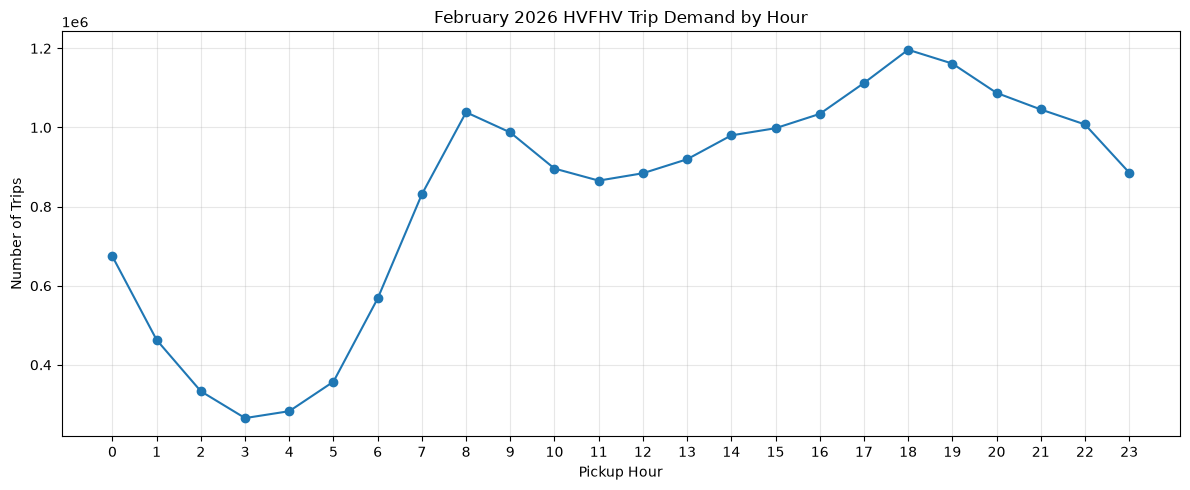

In [87]:
import matplotlib.pyplot as plt

plt.figure(figsize=(12, 5))

plt.plot(
    hourly_demand["pickup_hour"],
    hourly_demand["trip_count"],
    marker="o"
)

plt.xlabel("Pickup Hour")
plt.ylabel("Number of Trips")
plt.title("February 2026 HVFHV Trip Demand by Hour")
plt.xticks(range(24))
plt.grid(alpha=0.3)

plt.tight_layout()
plt.show()

## 3. Trip Duration by Hour

Trip duration can vary throughout the day due to changes in traffic conditions and travel patterns.

This analysis examines the average trip duration for each pickup hour to identify periods when trips tend to take longer or shorter.

In [88]:
# Calculate average trip duration by pickup hour

hourly_duration = (
    feb_analysis
    .groupby("pickup_hour")["trip_time"]
    .mean()
    .div(60)
    .reset_index(name="avg_trip_duration_minutes")
)

hourly_duration

,pickup_hour,avg_trip_duration_minutes
0,0,16.991416
1,1,16.525082
2,2,16.500716
3,3,17.027252
4,4,17.804328
5,5,19.059688
6,6,19.219666
7,7,19.492976
8,8,19.244943
9,9,18.858811


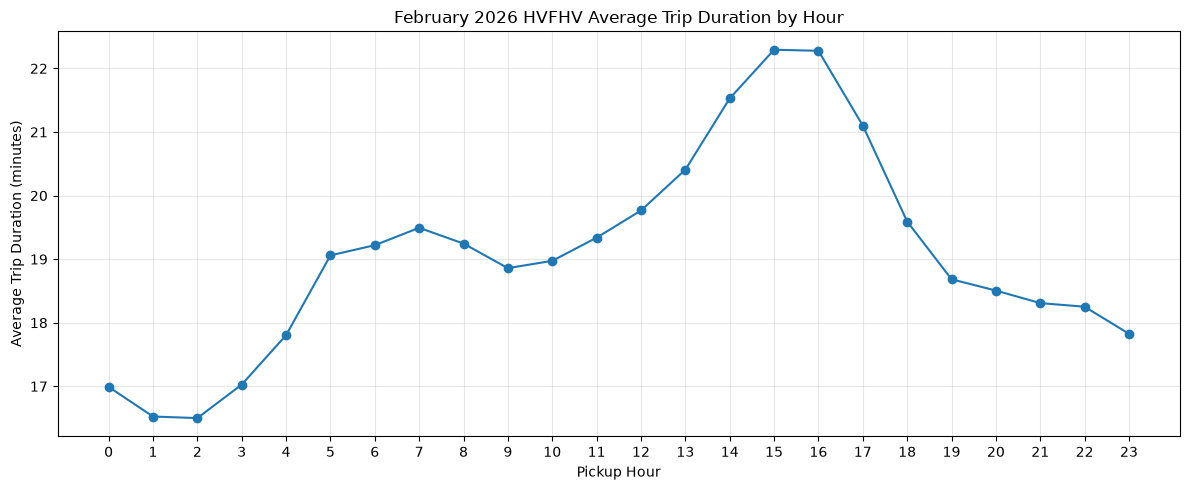

In [89]:
plt.figure(figsize=(12, 5))

plt.plot(
    hourly_duration["pickup_hour"],
    hourly_duration["avg_trip_duration_minutes"],
    marker="o"
)

plt.xlabel("Pickup Hour")
plt.ylabel("Average Trip Duration (minutes)")
plt.title("February 2026 HVFHV Average Trip Duration by Hour")
plt.xticks(range(24))
plt.grid(alpha=0.3)

plt.tight_layout()
plt.show()

## 4. Trip Distance by Hour

Trip distance provides another view of travel patterns across the day.

This analysis examines the average trip distance for each pickup hour to understand whether trips tend to be shorter or longer during different periods.

In [90]:
# Calculate average trip distance by pickup hour

hourly_distance = (
    feb_analysis
    .groupby("pickup_hour")["trip_miles"]
    .mean()
    .reset_index(name="avg_trip_distance_miles")
)

hourly_distance

,pickup_hour,avg_trip_distance_miles
0,0,4.881362
1,1,4.814867
2,2,4.968160
3,3,5.715253
4,4,6.643747
5,5,6.824178
6,6,5.851931
7,7,4.708787
8,8,4.177320
9,9,4.257379


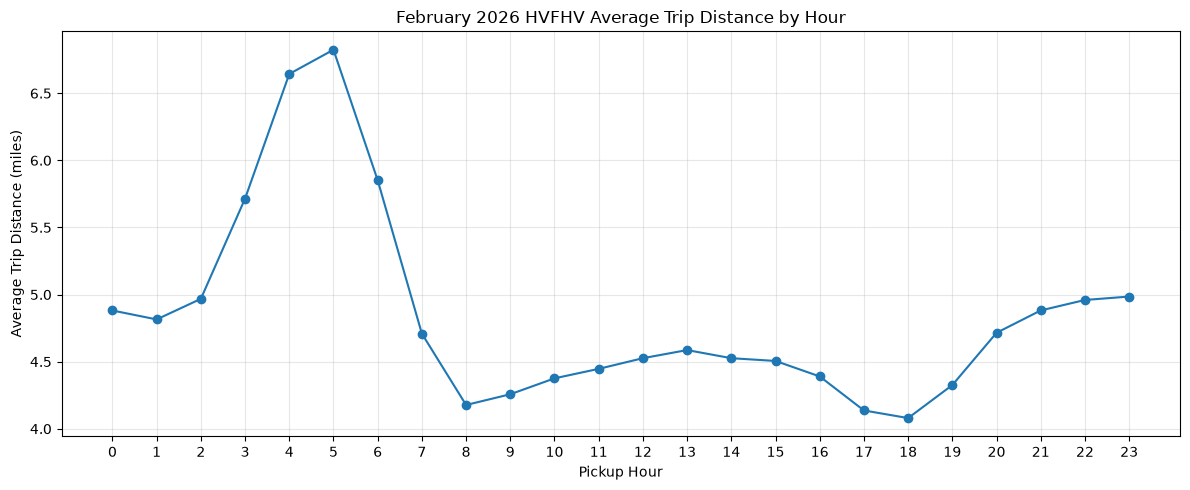

In [91]:
plt.figure(figsize=(12, 5))

plt.plot(
    hourly_distance["pickup_hour"],
    hourly_distance["avg_trip_distance_miles"],
    marker="o"
)

plt.xlabel("Pickup Hour")
plt.ylabel("Average Trip Distance (miles)")
plt.title("February 2026 HVFHV Average Trip Distance by Hour")
plt.xticks(range(24))
plt.grid(alpha=0.3)

plt.tight_layout()
plt.show()

## 5. Trip Volume by HVFHV Provider

Different High Volume For-Hire Vehicle providers may contribute different levels of trip activity.

This analysis compares total trip volume across providers using the HVFHV license number.

In [92]:
# Calculate trip volume by HVFHV provider

provider_demand = (
    feb_analysis
    .groupby("hvfhs_license_num")
    .size()
    .reset_index(name="trip_count")
    .sort_values("trip_count", ascending=False)
)

provider_demand

,hvfhs_license_num,trip_count
0,HV0003,14166961
1,HV0005,5708725


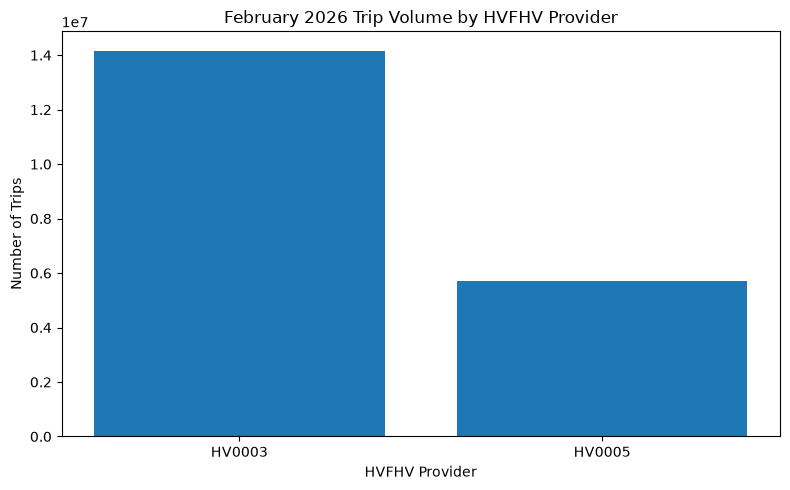

In [93]:
plt.figure(figsize=(8, 5))

plt.bar(
    provider_demand["hvfhs_license_num"],
    provider_demand["trip_count"]
)

plt.xlabel("HVFHV Provider")
plt.ylabel("Number of Trips")
plt.title("February 2026 Trip Volume by HVFHV Provider")

plt.tight_layout()
plt.show()

## 6. Trip Demand by Pickup Location

Pickup location helps identify areas generating the highest volume of HVFHV trips.

This analysis ranks pickup locations by total trip volume using the NYC TLC Pickup Location ID.

In [94]:
# Calculate trip demand by pickup location

pickup_demand = (
    feb_analysis
    .groupby("PULocationID")
    .size()
    .reset_index(name="trip_count")
    .sort_values("trip_count", ascending=False)
)

pickup_demand.head(15)

,PULocationID,trip_count
135,138,341205
129,132,273543
60,61,259773
75,76,241178
78,79,229729
36,37,227591
158,161,213444
228,231,209641
227,230,207136
109,112,202694


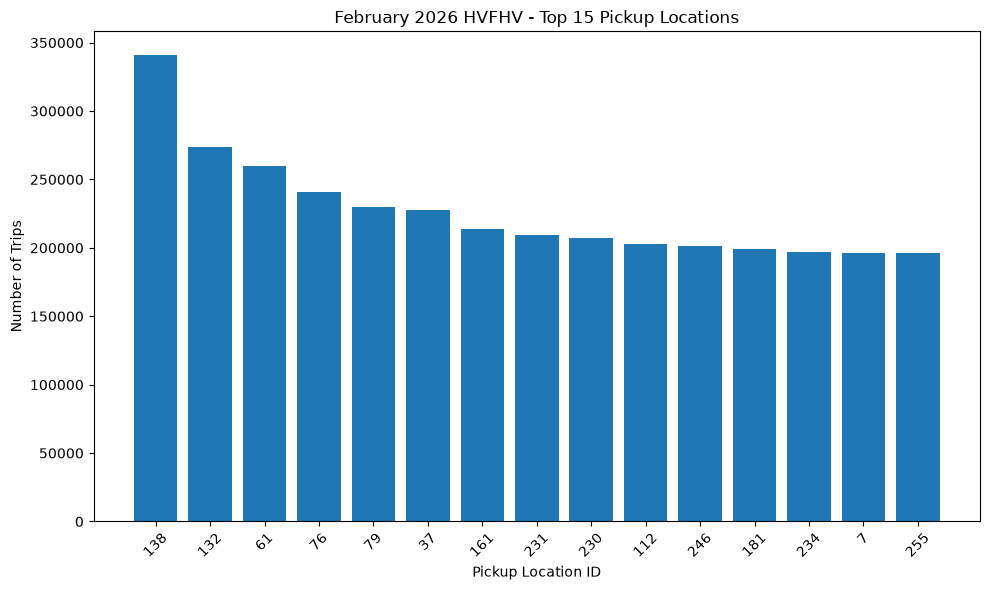

In [95]:
import matplotlib.pyplot as plt

top_pickup = pickup_demand.head(15)

plt.figure(figsize=(10, 6))

plt.bar(
    top_pickup["PULocationID"].astype(str),
    top_pickup["trip_count"]
)

plt.xlabel("Pickup Location ID")
plt.ylabel("Number of Trips")
plt.title("February 2026 HVFHV - Top 15 Pickup Locations")

plt.xticks(rotation=45)
plt.tight_layout()
plt.show()

## 7. Trip Demand by Drop-off Location

Drop-off location helps identify areas receiving the highest volume of HVFHV trips.

This analysis ranks drop-off locations by total trip volume using the NYC TLC Drop-off Location ID.

In [96]:
# Calculate trip demand by drop-off location

dropoff_demand = (
    feb_analysis
    .groupby("DOLocationID")
    .size()
    .reset_index(name="trip_count")
    .sort_values("trip_count", ascending=False)
)

dropoff_demand.head(15)

,DOLocationID,trip_count
261,265,821845
135,138,365192
129,132,346033
60,61,275260
75,76,238581
36,37,230614
109,112,200970
178,181,199580
6,7,192556
78,79,190923


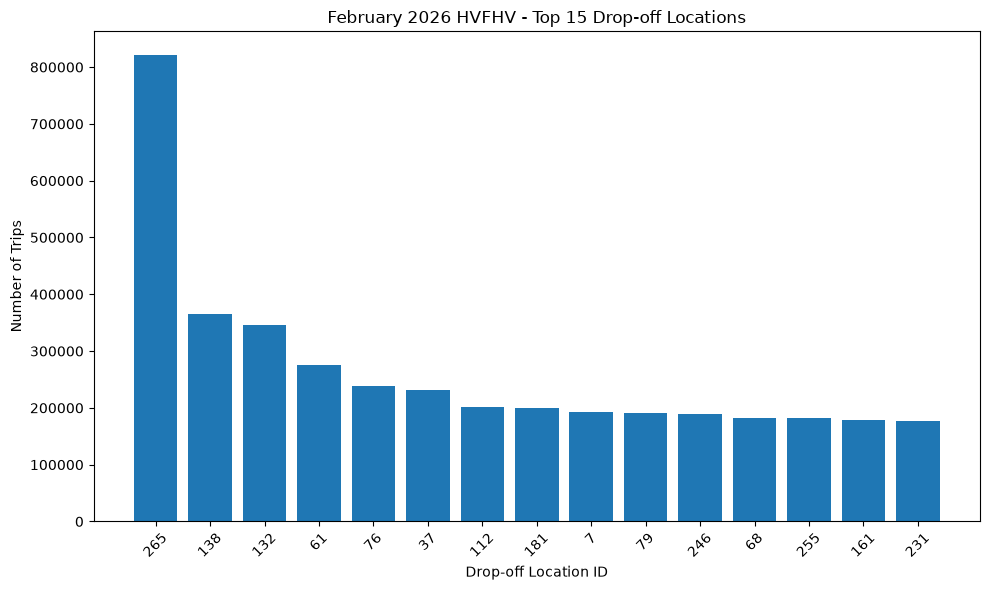

In [97]:
top_dropoff = dropoff_demand.head(15)

plt.figure(figsize=(10, 6))

plt.bar(
    top_dropoff["DOLocationID"].astype(str),
    top_dropoff["trip_count"]
)

plt.xlabel("Drop-off Location ID")
plt.ylabel("Number of Trips")
plt.title("February 2026 HVFHV - Top 15 Drop-off Locations")

plt.xticks(rotation=45)
plt.tight_layout()
plt.show()

## 8. Revenue by HVFHV Provider

Trip volume shows how many trips each provider handles, while revenue metrics help compare the financial contribution of each provider.

This analysis compares total and average base passenger fare across HVFHV providers.

In [98]:
# Calculate revenue metrics by HVFHV provider

provider_revenue = (
    feb_analysis
    .groupby("hvfhs_license_num")
    .agg(
        total_base_fare=("base_passenger_fare", "sum"),
        average_base_fare=("base_passenger_fare", "mean"),
        total_driver_pay=("driver_pay", "sum"),
        average_driver_pay=("driver_pay", "mean")
    )
    .reset_index()
    .sort_values("total_base_fare", ascending=False)
)

provider_revenue

,hvfhs_license_num,total_base_fare,average_base_fare,total_driver_pay,average_driver_pay
0,HV0003,3.896827e+08,27.506443,2.992867e+08,21.125684
1,HV0005,1.396221e+08,24.457663,1.088601e+08,19.069083


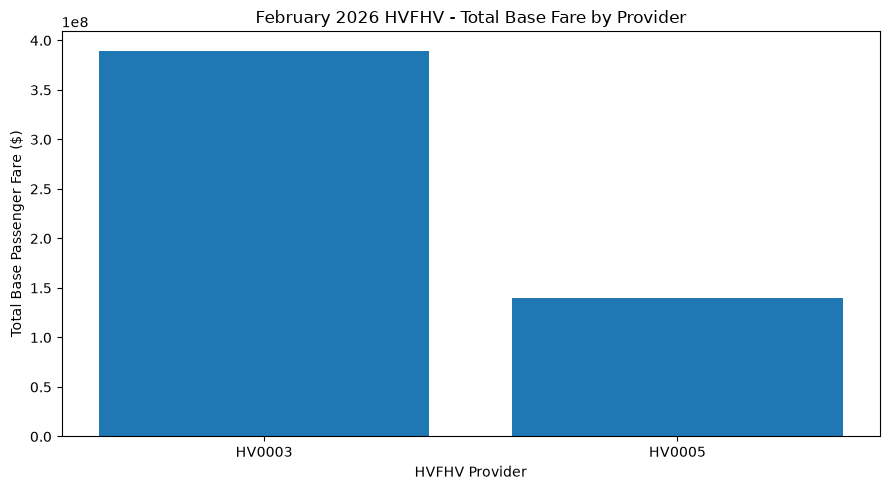

In [99]:
plt.figure(figsize=(9, 5))

plt.bar(
    provider_revenue["hvfhs_license_num"],
    provider_revenue["total_base_fare"]
)

plt.xlabel("HVFHV Provider")
plt.ylabel("Total Base Passenger Fare ($)")
plt.title("February 2026 HVFHV - Total Base Fare by Provider")

plt.tight_layout()
plt.show()

## 9. Tipping Behavior by Hour

Tipping patterns can provide insight into how rider payment behavior changes throughout the day.

This analysis examines total tips and average tips per trip by pickup hour.

In [100]:
# Calculate tipping metrics by pickup hour

hourly_tips = (
    feb_analysis
    .groupby("pickup_hour")
    .agg(
        total_tips=("tips", "sum"),
        average_tip=("tips", "mean")
    )
    .reset_index()
)

hourly_tips

,pickup_hour,total_tips,average_tip
0,0,640374.58,0.950283
1,1,385878.54,0.833550
2,2,257852.07,0.773926
3,3,238056.50,0.896888
4,4,373046.58,1.318750
5,5,527581.08,1.475743
6,6,715318.23,1.259929
7,7,968847.04,1.165616
8,8,1147682.70,1.105190
9,9,1108810.00,1.122977


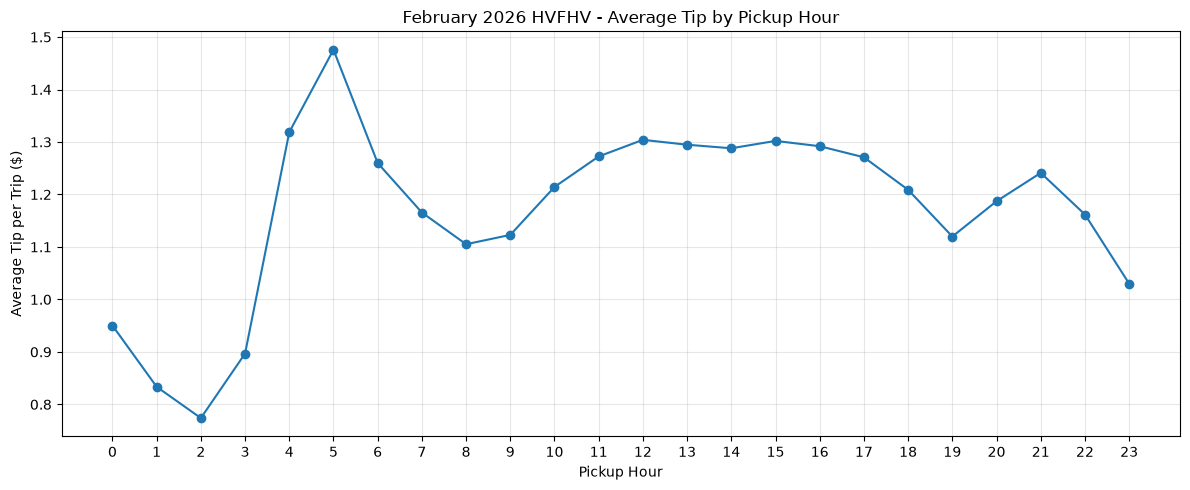

In [101]:
plt.figure(figsize=(12, 5))

plt.plot(
    hourly_tips["pickup_hour"],
    hourly_tips["average_tip"],
    marker="o"
)

plt.xlabel("Pickup Hour")
plt.ylabel("Average Tip per Trip ($)")
plt.title("February 2026 HVFHV - Average Tip by Pickup Hour")

plt.xticks(range(24))
plt.grid(alpha=0.3)

plt.tight_layout()
plt.show()

## 10. Shared Ride Behavior

Shared-ride indicators help understand the extent to which passengers requested pooled trips.

This analysis examines the distribution of trips based on the `shared_request_flag`.

In [102]:
shared_requests = (
    feb_analysis["shared_request_flag"]
    .value_counts()
    .reset_index()
)

shared_requests.columns = ["shared_request_flag", "trip_count"]

shared_requests

,shared_request_flag,trip_count
0,N,19489921
1,Y,385765


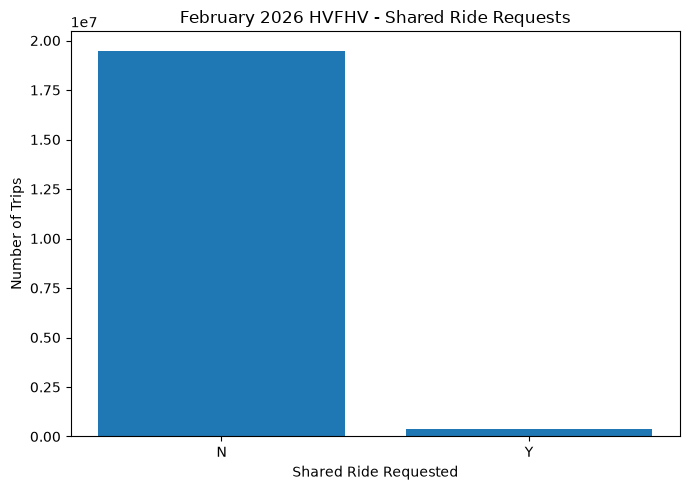

In [103]:
import matplotlib.pyplot as plt

plt.figure(figsize=(7, 5))

plt.bar(
    shared_requests["shared_request_flag"],
    shared_requests["trip_count"]
)

plt.xlabel("Shared Ride Requested")
plt.ylabel("Number of Trips")
plt.title("February 2026 HVFHV - Shared Ride Requests")

plt.tight_layout()
plt.show()

## 11. Trip Distance Distribution

Trip distance helps understand the typical travel range of HVFHV trips.

This analysis examines the distribution of trip distances to identify:

- The typical trip distance
- The concentration of short and medium-distance trips
- Extremely long trips that may represent unusual observations

Understanding the distribution helps determine whether the average trip distance is representative of most trips.

In [104]:
# Summary statistics for trip distance

distance_summary = feb_analysis["trip_miles"].describe()

distance_summary

count    1.987569e+07
mean     4.649153e+00
std      5.598391e+00
min      0.000000e+00
25%      1.408000e+00
50%      2.690000e+00
75%      5.740000e+00
max      1.625940e+03
Name: trip_miles, dtype: float64

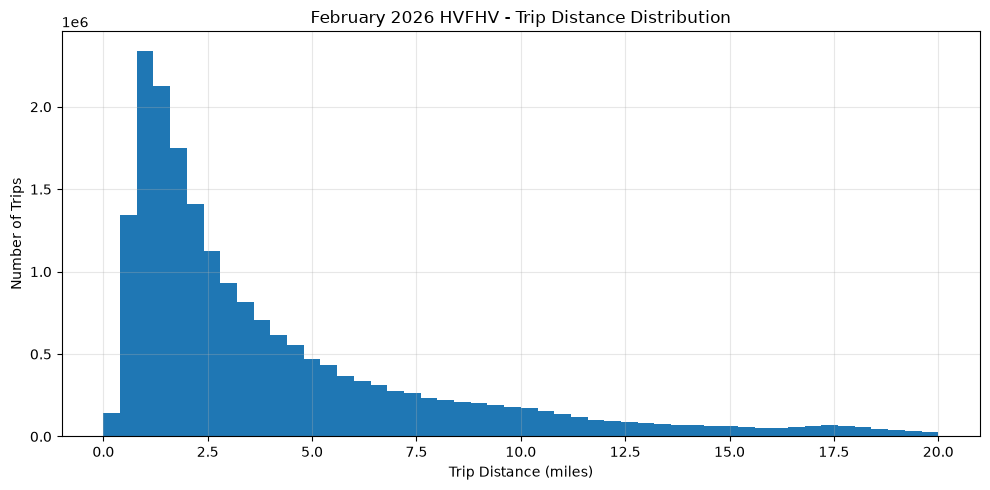

In [105]:
plt.figure(figsize=(10, 5))

plt.hist(
    feb_analysis["trip_miles"],
    bins=50,
    range=(0, 20)
)

plt.xlabel("Trip Distance (miles)")
plt.ylabel("Number of Trips")
plt.title("February 2026 HVFHV - Trip Distance Distribution")
plt.grid(alpha=0.3)

plt.tight_layout()
plt.show()

## 12. Trip Duration Distribution

Trip duration provides another measure of typical HVFHV travel behavior.

This analysis examines how trip durations are distributed across February 2026 to identify:

- The typical trip duration
- The concentration of shorter and longer trips
- Extremely long trips that may represent unusual observations

The distribution helps provide context for the average trip duration observed earlier.

In [106]:
# Summary statistics for trip duration

duration_summary = (feb_analysis["trip_time"] / 60).describe()

duration_summary

count    1.987569e+07
mean     1.937709e+01
std      1.372940e+01
min      0.000000e+00
25%      9.750000e+00
50%      1.581667e+01
75%      2.503333e+01
max      6.766333e+02
Name: trip_time, dtype: float64

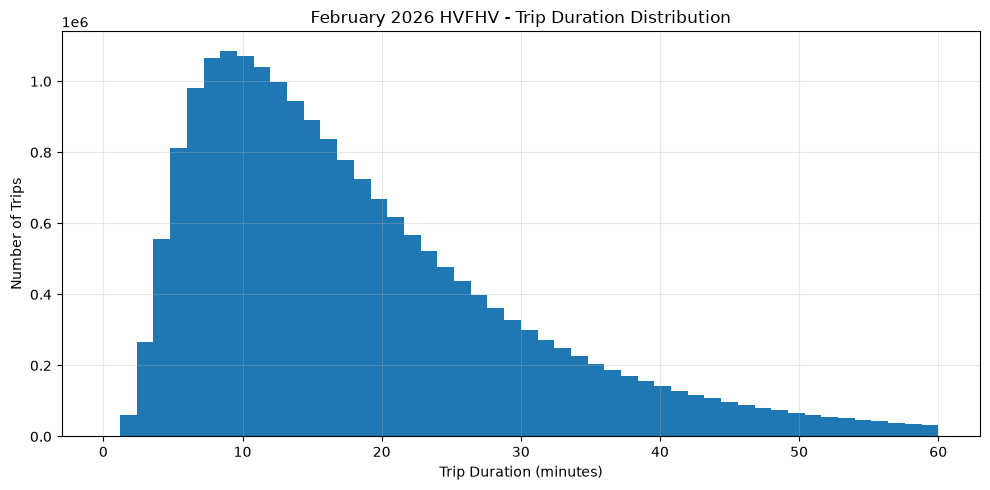

In [107]:
plt.figure(figsize=(10, 5))

plt.hist(
    feb_analysis["trip_time"] / 60,
    bins=50,
    range=(0, 60)
)

plt.xlabel("Trip Duration (minutes)")
plt.ylabel("Number of Trips")
plt.title("February 2026 HVFHV - Trip Duration Distribution")
plt.grid(alpha=0.3)

plt.tight_layout()
plt.show()

## 13. Average Fare by Trip Distance

Trip distance is an important factor influencing the fare charged for a trip.

This analysis examines the relationship between trip distance and average base passenger fare to understand how fare levels change as trips become longer.

The analysis helps identify:
- Whether longer trips generally result in higher fares
- The relationship between trip distance and passenger fare
- Any unusual distance ranges where the fare pattern differs from the overall trend

In [108]:
# Calculate average base fare by trip distance

fare_by_distance = (
    feb_analysis
    .groupby("trip_miles")["base_passenger_fare"]
    .mean()
    .reset_index(name="avg_base_fare")
)

fare_by_distance.head()

,trip_miles,avg_base_fare
0,0.000,12.249698
1,0.001,23.240000
2,0.002,5.450000
3,0.007,9.432529
4,0.010,11.615430


In [109]:
# Create meaningful trip distance bands

distance_bins = [0, 2, 5, 10, 15, 20, float("inf")]
distance_labels = [
    "0–2 miles",
    "2–5 miles",
    "5–10 miles",
    "10–15 miles",
    "15–20 miles",
    "20+ miles"
]

feb_analysis["distance_band"] = pd.cut(
    feb_analysis["trip_miles"],
    bins=distance_bins,
    labels=distance_labels,
    include_lowest=True
)

fare_by_distance_band = (
    feb_analysis
    .groupby("distance_band", observed=False)["base_passenger_fare"]
    .agg(
        average_fare="mean",
        trip_count="count"
    )
    .reset_index()
)

fare_by_distance_band

,distance_band,average_fare,trip_count
0,0–2 miles,12.897763,7736790
1,2–5 miles,22.520231,6381731
2,5–10 miles,35.724497,3458948
3,10–15 miles,52.859208,1249534
4,15–20 miles,76.158644,646704
5,20+ miles,116.744351,401979


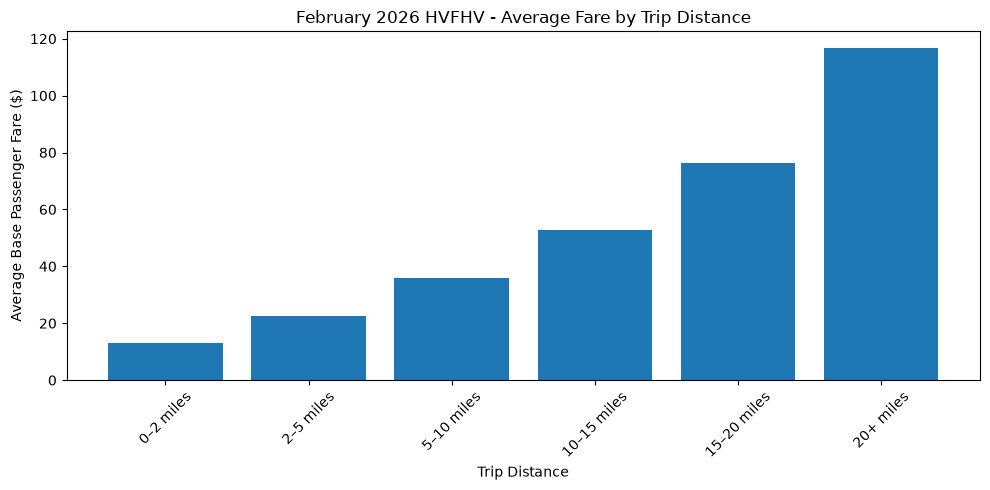

In [110]:
# Plot average base fare by trip distance band

plt.figure(figsize=(10, 5))

plt.bar(
    fare_by_distance_band["distance_band"],
    fare_by_distance_band["average_fare"]
)

plt.xlabel("Trip Distance")
plt.ylabel("Average Base Passenger Fare ($)")
plt.title("February 2026 HVFHV - Average Fare by Trip Distance")

plt.xticks(rotation=45)
plt.tight_layout()
plt.show()

## 14. Tipping Behavior by Base Fare

Base passenger fare represents the fare charged before tolls, tips, taxes, and fees.

This analysis examines how average tip amounts vary across different base-fare ranges to understand whether higher-fare trips are associated with different tipping behavior.

The analysis helps identify:
- How average tips vary across fare ranges
- Whether higher-fare trips tend to receive higher tips
- The relationship between trip fare level and tipping behavior

In [111]:
# Create base fare bands for tipping analysis

fare_bins = [-float("inf"), 10, 20, 40, 60, 100, float("inf")]
fare_labels = [
    "Below $10",
    "$10–20",
    "$20–40",
    "$40–60",
    "$60–100",
    "$100+"
]

feb_analysis["fare_band"] = pd.cut(
    feb_analysis["base_passenger_fare"],
    bins=fare_bins,
    labels=fare_labels
)

tip_by_fare = (
    feb_analysis
    .groupby("fare_band", observed=False)["tips"]
    .agg(
        average_tip="mean",
        trip_count="count"
    )
    .reset_index()
)

tip_by_fare

,fare_band,average_tip,trip_count
0,Below $10,0.348409,3159784
1,$10–20,0.531962,7163293
2,$20–40,1.066512,6153319
3,$40–60,2.271244,1924436
4,$60–100,4.132652,1097498
5,$100+,8.605254,377356


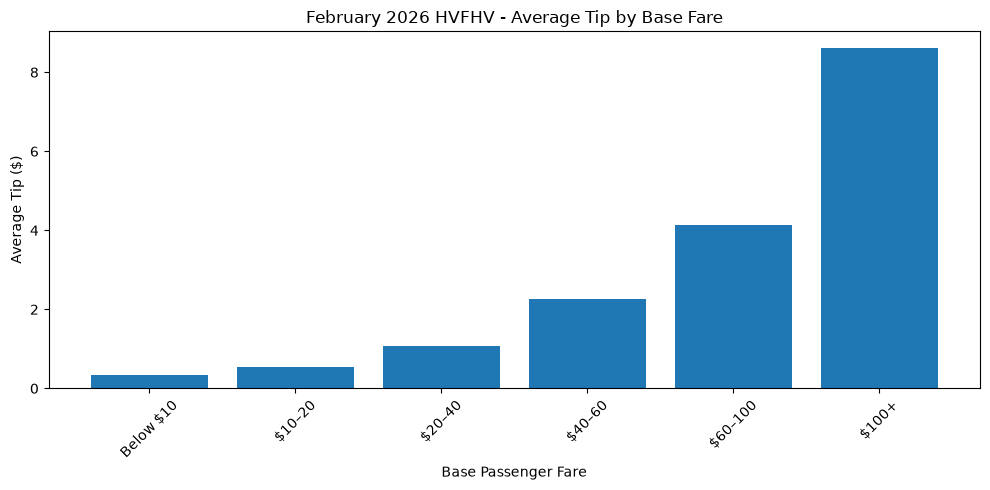

In [112]:
# Plot average tip by base fare band

plt.figure(figsize=(10, 5))

plt.bar(
    tip_by_fare["fare_band"],
    tip_by_fare["average_tip"]
)

plt.xlabel("Base Passenger Fare")
plt.ylabel("Average Tip ($)")
plt.title("February 2026 HVFHV - Average Tip by Base Fare")

plt.xticks(rotation=45)
plt.tight_layout()
plt.show()

## 15. HVFHV Provider Performance Comparison

Different HVFHV providers may differ in trip volume, fare levels, driver pay, and trip characteristics.

This analysis compares the performance of HVFHV providers across key operational and financial metrics.

The analysis examines:
- Total number of trips handled by each provider
- Average base passenger fare
- Average driver pay
- Average trip distance

Comparing these metrics provides a broader view of how provider activity and financial metrics differ during February 2026.

In [113]:
# Calculate key performance metrics by HVFHV provider

provider_performance = (
    feb_analysis
    .groupby("hvfhs_license_num")
    .agg(
        trip_count=("hvfhs_license_num", "size"),
        average_base_fare=("base_passenger_fare", "mean"),
        average_driver_pay=("driver_pay", "mean"),
        average_trip_distance=("trip_miles", "mean")
    )
    .reset_index()
    .sort_values("trip_count", ascending=False)
)

provider_performance

,hvfhs_license_num,trip_count,average_base_fare,average_driver_pay,average_trip_distance
0,HV0003,14166961,27.506443,21.125684,4.825880
1,HV0005,5708725,24.457663,19.069083,4.210583


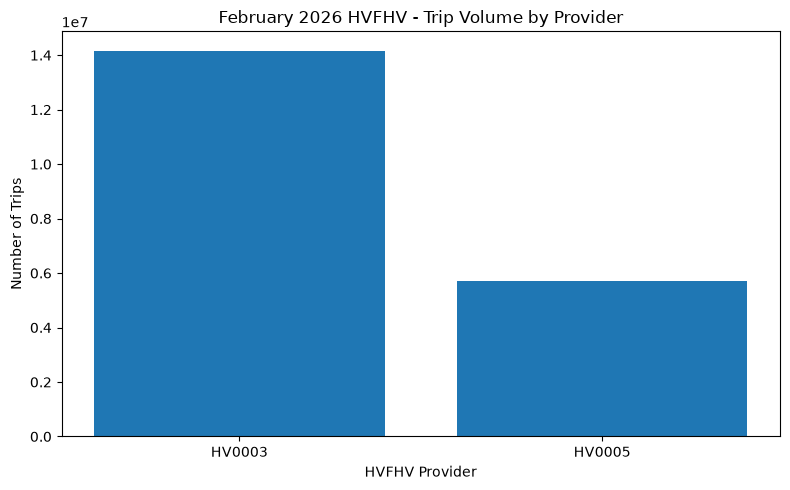

In [114]:
 # Plot trip volume by HVFHV provider

plt.figure(figsize=(8, 5))

plt.bar(
    provider_performance["hvfhs_license_num"],
    provider_performance["trip_count"]
)

plt.xlabel("HVFHV Provider")
plt.ylabel("Number of Trips")
plt.title("February 2026 HVFHV - Trip Volume by Provider")

plt.tight_layout()
plt.show()

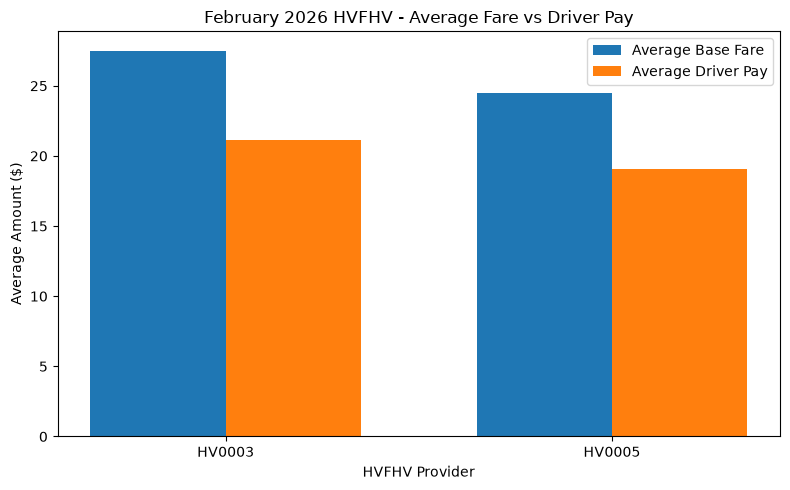

In [115]:
# Compare average base fare and average driver pay by provider

x = range(len(provider_performance))

width = 0.35

plt.figure(figsize=(8, 5))

plt.bar(
    [i - width / 2 for i in x],
    provider_performance["average_base_fare"],
    width=width,
    label="Average Base Fare"
)

plt.bar(
    [i + width / 2 for i in x],
    provider_performance["average_driver_pay"],
    width=width,
    label="Average Driver Pay"
)

plt.xlabel("HVFHV Provider")
plt.ylabel("Average Amount ($)")
plt.title("February 2026 HVFHV - Average Fare vs Driver Pay")

plt.xticks(x, provider_performance["hvfhs_license_num"])
plt.legend()

plt.tight_layout()
plt.show()